In [3]:
#import common library/function

import google.auth
import google.auth.impersonated_credentials
from concurrent.futures import TimeoutError
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from google.cloud import bigquery

In [4]:
client = bigquery.Client(project="ingka-pmp-fixa-dev")


/Users/salvatore.lovecchio/Library/Python/3.9/lib/python/site-packages/google/auth/_default.py:76: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
Python(81114) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


## Queries collection

In [5]:
##sec 1: Overall task distribution type
code=""" 
SELECT
  task_type,
  FORMAT_DATE('%Y-%m', DATE(created_local_dt)) AS year_month,
  COUNT(DISTINCT task_id) AS distinct_task,
FROM
  `ingka-pmp-fixa-prod.report_fixa.task_overview`
WHERE
  created_local_dt BETWEEN '2024-09-01'
  AND '2025-07-31'
GROUP BY
  1,
  2
"""

job=client.query(code)

task_overview=job.to_dataframe()

E0000 00:00:1768908609.988255 4979151 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [6]:
##sec 2.1: Overall task null distribution
code=""" 
SELECT
  COUNT(DISTINCT task_id) AS distinct_task,
  COUNT(DISTINCT
  IF
    (item_no IS NULL,task_id,NULL) ) AS task_id_item_null,
  COUNT(DISTINCT
  IF
    (item_name IS NULL,task_id,NULL) ) AS task_id_item_name_null,
  COUNT(DISTINCT
  IF
    (item_family_name IS NULL,task_id,NULL) ) AS task_id_item_family_name_null,
  COUNT(DISTINCT
  IF
    (item_pa_no IS NULL,task_id,NULL) ) AS task_id_pa_no_null,
  COUNT(DISTINCT
  IF
    (item_pa_name IS NULL,task_id,NULL) ) AS task_id_pa_name_null,
  COUNT(DISTINCT
  IF
    (item_pra_no IS NULL,task_id,NULL) ) AS task_id_pra_no_null,
  COUNT(DISTINCT
  IF
    (item_pra_name IS NULL,task_id,NULL) ) AS task_id_pra_name_null,
  COUNT(DISTINCT
  IF
    (item_hfb_no IS NULL,task_id,NULL) ) AS task_id_item_hfb_no_null,
  COUNT(DISTINCT
  IF
    (item_hfb_name IS NULL,task_id,NULL) ) AS task_id_item_hfb_name_null,
  COUNT(DISTINCT
  IF
    (item_hfb_no_name IS NULL,task_id,NULL) ) AS task_id_item_hfb_no_name_null,
  COUNT(DISTINCT
  IF
    (item_type IS NULL,task_id,NULL) ) AS task_item_type_null,
  COUNT(DISTINCT
  IF
    (item_name IS NULL,task_id,NULL) ) AS task_item_name_null,
  COUNT(DISTINCT
  IF
    (item_home_location_grid_code IS NULL,task_id,NULL) ) AS task_item_home_location_grid_code_null
FROM
  `ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks`
WHERE
  1=1
  AND DATE(created_utc_dttm) BETWEEN '2024-09-01'
  AND '2025-07-31'

"""

job=client.query(code)

task_null_validation=job.to_dataframe()

E0000 00:00:1768908613.001741 4979151 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [7]:
#sec 2.2: Loading distribution location by refill

code=""" 
select --item_hfb_name, 
item_fill_location_department_name,
       count(distinct item_fill_location_grid_code) as number_of_different_grid_code
from ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks
where 1=1
      and date(created_local_dt) between '2024-09-01' and '2025-08-31'
     -- and item_hfb_name is not null
group by item_fill_location_department_name
"""

job=client.query(code)

item_refill_location=job.to_dataframe()

E0000 00:00:1768908615.250470 4979151 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [9]:
#sec 2.2: Loading distribution location by refill by month

code=""" 
select 
    FORMAT_DATE('%Y-%m', created_local_dt) AS year_month,
item_fill_location_department_name,
       count(distinct item_fill_location_grid_code) as number_of_different_grid_code
from `ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks`
where 1=1
      and date(created_local_dt) between '2023-09-01' and '2025-12-31'
group by 1,2
order by 1,2
"""

job=client.query(code)

item_refill_location_month=job.to_dataframe()

E0000 00:00:1768908647.202332 4979151 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [119]:
#sec 2.3.0: Loading number of task with refilled qty

##sec 2.3.1: Loading difference request vs refilled

#sec 2.3.2: Loading difference betweek picked vs refilled 

## sec 2.3.3 : Overall task distribution type


code=""" 
SELECT  
    DATE(created_utc_dttm) AS task_created_date,
    FORMAT_DATE('%Y-%m', DATE(created_utc_dttm)) AS year_month,
    task_id,
    store_no_name,
    item_no,
    item_name,
    item_price_eur,
    filled_qty,  
    requested_qty, 
    refilled_qty,
    picked_qty,
    requested_qty - refilled_qty AS difference_requested_refilled,
    picked_qty - refilled_qty AS difference_picked_refilled
FROM ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks
WHERE 1=1
    AND ( (DATE(created_utc_dttm) BETWEEN '2024-09-01' AND '2024-09-31') OR 
    ((DATE(created_utc_dttm) BETWEEN '2025-09-01' AND '2025-09-31'))
    AND fill_type = 'REGULAR'
    AND fill_home_flag = FALSE
    AND completed_local_dt IS NOT NULL
    AND filled_qty IS NOT NULL
    AND refilled_qty IS NOT NULL
    AND picked_qty IS NOT NULL
"""
job=client.query(code)

addons_refill_difference=job.to_dataframe()

BadRequest: 400 Syntax error: Expected "," but got end of script at [25:31]; reason: invalidQuery, location: query, message: Syntax error: Expected "," but got end of script at [25:31]

Location: EU
Job ID: bd531ff2-6434-4767-a56f-fb48814f2b3e


In [11]:

#sec 2.4 Code time between test
code=""" 
select task_id, 
       difference_in_seconds
from(
select task_id,
       store_no_name,
       created_local_dt,  
       row_number() over(order by created_local_dt) as order_survey, 
       lag(created_local_dt) over(order by created_local_dt) as previous_timestamp, 
       timestamp_diff(created_local_dt,lag(created_local_dt) over(order by created_local_dt),SECOND) as difference_in_seconds, 
       case when lag(date(created_local_dt)) over(order by date(created_local_dt))!=date(created_local_dt) then 1 else 0 end as flag
from ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks
where 1=1
      and date(created_local_dt) between '2024-09-01' and '2025-07-31'
     -- and store_no='501'
order by created_local_dt)
where 1=1
      and flag=0
      and difference_in_seconds is not null
"""

job=client.query(code)

addons_time_between_tasks=job.to_dataframe()

KeyboardInterrupt: 

In [111]:
#sec 2.4 Loading the time completed task


code=""" 
      select lag_created_completed_minute
      from ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks
      where 1=1
            and date(created_utc_dttm) between '2024-09-01' and '2025-07-31'
            --and fill_type='REGULAR'
            --and refill_home_flag=false
            and completed_local_dt is not null
            --and refilled_qty is not null
"""

job=client.query(code)

created_completed_June24=job.to_dataframe()

In [64]:
##sec 2.5.1 : Overall validation length grid code =6
code=""" 
SELECT
  FORMAT_DATE('%Y-%m', DATE(created_local_dt)) AS year_month,
  COUNT(DISTINCT
  IF
    (LENGTH(item_fill_location_grid_code) !=6, item_fill_location_grid_code,NULL)) AS incorrect_grid_length,
  COUNT(DISTINCT
  IF
    (LENGTH(item_fill_location_grid_code) =6, item_fill_location_grid_code,NULL)) AS correct_grid_length,
  COUNT(DISTINCT item_fill_location_grid_code) AS total_distinc_grid,
  COUNT(DISTINCT
  IF
    (LENGTH(item_fill_location_grid_code) !=6, item_fill_location_grid_code,NULL))/COUNT(DISTINCT item_fill_location_grid_code) AS perc_incorrect_grid_length,
  COUNT(DISTINCT
  IF
    (LENGTH(item_fill_location_grid_code) =6, item_fill_location_grid_code,NULL))/COUNT(DISTINCT item_fill_location_grid_code) AS perc_correct_grid_length,
FROM
  `ingka-pmp-fixa-prod.report_fixa.addon_insight_all_tasks`
WHERE
  1=1
  AND DATE(created_local_dt) BETWEEN '2023-09-01'
  AND '2025-11-30'
  and item_fill_location_department_no ='OT'
GROUP BY
  1
ORDER BY
  1 asc

"""

job=client.query(code)

task_grid_validation=job.to_dataframe()


E0000 00:00:1765466861.388645 1246392 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [103]:
##sec 2.5.2 : loading validation grid code
code=""" 
WITH
  filtered_data AS (
  SELECT
    cal.ikea_week_no,
    cal.iso_month_no,
    fixa.store_no,
    fixa.store_no_name,
    fixa.item_no,
    fixa.item_fill_location_grid_code,
    DATE(fixa.created_utc_dttm) AS create_date
  FROM
    `ingka-pmp-fixa-prod.report_fixa.addon_insight_completed_tasks` fixa
  LEFT JOIN
       `ingka-sbpdp-ecbd-prod.dm_calendar_ref_no_pii.calendar_dim_v` cal
  ON
    DATE(fixa.created_utc_dttm) = cal.day_date
  WHERE
    1=1
    AND DATE(created_utc_dttm) >= '2023-09-01' AND DATE(created_utc_dttm) <= '2025-12-31' ),
  -- Get data from SLM to join for assigned sale_space_quantity
  slm_data AS (
  SELECT
    article_id,
    bu_code,
    sales_location_id,
    CASE
      WHEN location_type = '1' THEN 'H'
      WHEN location_type = '2' THEN 'P'
      ELSE ' '
  END
    AS location_type_derived,
    location_type,
    assigned_sales_space_quantity,
    PARSE_DATE('%Y%m%d', from_date) AS from_date,
    # nex import_date is the until_date with the condition of row_numb = 1
    import_date as till_date,
    active,
ROW_NUMBER() OVER (PARTITION BY article_id, bu_code, sales_location_id, from_date
ORDER BY CAST(import_date AS DATE) DESC) AS row_num
  FROM
    `ingka-cff-slm-prod.slm.article_location_weekly`
  WHERE
    import_date >= '2023-09-01'
 Qualify row_num = 1 ),
  unique_store_location_set AS (
  SELECT
    DISTINCT fd.ikea_week_no,
    fd.iso_month_no,
    fd.store_no,
    fd.store_no_name,
    fd.item_fill_location_grid_code,
    CASE
      WHEN fd.item_fill_location_grid_code = slm.sales_location_id THEN 1
      WHEN  slm.sales_location_id is null THEN 0
      ELSE 0
  END
    AS valid_grid_code,
    slm.location_type
  FROM
    filtered_data AS fd
  LEFT JOIN
    slm_data AS slm
  ON
    1=1
    AND slm.article_id = fd.item_no
    AND fd.item_fill_location_grid_code = slm.sales_location_id
    AND fd.create_date >= slm.from_date
    AND (fd.create_date <= slm.till_date      )
    AND fd.store_no = slm.bu_code 
    AND ( slm.location_type = '0'
        OR slm.location_type  is null)
    )
SELECT
  ikea_week_no,
  iso_month_no,
  store_no,
  store_no_name,
  COUNT(*) AS total_grid_codes,
  SUM(valid_grid_code) AS total_valid_grid_codes
FROM
  unique_store_location_set
GROUP BY
  ikea_week_no,
  store_no,
  store_no_name, 
  iso_month_no

"""

job=client.query(code)

task_location=job.to_dataframe()

E0000 00:00:1769123040.280464 4979151 alts_credentials.cc:93] ALTS creds ignored. Not running on GCP and untrusted ALTS is not enabled.


In [14]:
##sec 2.5.3 : Data validation SLM
code=""" 
select article_id, bu_code, sales_location_id, from_date, import_date, location_type from (
SELECT
    article_id,
    bu_code,
    sales_location_id,
    CASE
      WHEN location_type = '1' THEN 'H'
      WHEN location_type = '2' THEN 'P'
      WHEN location_type = '3' THEN 'HP'
      WHEN location_type = '0' THEN 'N'
      ELSE ' '
  END
    AS location_type_derived,
    location_type,
    assigned_sales_space_quantity,
    PARSE_DATE('%Y%m%d', from_date) AS from_date,
    import_date ,
    active
  FROM
    `ingka-cff-slm-prod.slm.article_location_weekly`
  WHERE
    bu_code = '087' and
    import_date >= '2025-03-01' and import_date <= '2025-03-31'
)


"""

job=client.query(code)

check_location_id=job.to_dataframe()

In [15]:
##sec 2.5.3.1 Data validation slm 2
code=""" 
WITH
  count_unique_loc AS(
  SELECT
    article_id,
    bu_code,
    sales_location_id,
    import_date,
    COUNT(DISTINCT location_type) AS daily_unique_location_type
  FROM (
    SELECT
      article_id,
      bu_code,
      sales_location_id,
      location_type,
      assigned_sales_space_quantity,
      PARSE_DATE('%Y%m%d', from_date) AS from_date,
      # nex import_date is the until_date with the condition of row_numb = 1
      import_date,
      active,
      ROW_NUMBER() OVER (PARTITION BY article_id, bu_code, sales_location_id ORDER BY CAST(import_date AS DATE) DESC) AS row_num
    FROM
      `ingka-cff-slm-prod.slm.article_location_weekly`
    WHERE
      -- bu_code = '087'
      -- AND
      import_date >= '2025-03-01'
      AND import_date <= '2025-03-31'
      --Qualify row_num = 1
      )
  GROUP BY
    article_id,
    bu_code,
    sales_location_id,
    import_date )
SELECT
  bu_code,
  SUM(CASE
      WHEN daily_unique_location_type = 1 THEN 1
      ELSE 0
  END
    ) AS oneloc,
  SUM(CASE
      WHEN daily_unique_location_type != 1 THEN 1
      ELSE 0
  END
    ) AS gt1loc,
  100*SUM(CASE
      WHEN daily_unique_location_type != 1 THEN 1
      ELSE 0
  END
    )/SUM(CASE
      WHEN daily_unique_location_type = 1 THEN 1
      ELSE 0
  END
    ) AS perc
FROM
  count_unique_loc
GROUP BY
  1


"""

job=client.query(code)

check_uniq_location_type=job.to_dataframe()

# Section 1 : Overall task distribution

In [16]:
grouped_month=task_overview.groupby(['year_month']).agg({
           'distinct_task' : ['sum']
        }).reset_index()


grouped_month.columns = grouped_month.columns.map('_'.join)
grouped_month.rename(columns = {
                                'year_month_' : 'year_month',
                      'distinct_task_sum' : 'distinct_task_tot'
                         }, inplace = True)
grouped_month.head()

,year_month,distinct_task_tot
0,2024-09,795782
1,2024-10,860989
2,2024-11,930976
3,2024-12,957543
4,2025-01,1044082


In [17]:
merged = pd.merge(task_overview, grouped_month, on=[ 'year_month'], how= 'left')

merged['ratio'] = 100.*merged['distinct_task']/merged['distinct_task_tot']

merged.head()

,task_type,year_month,distinct_task,distinct_task_tot,ratio
0,PRODUCT_QUALITY,2025-02,3890,961809,0.404446
1,ADDON,2025-06,919270,1016096,90.470782
2,ADDON,2024-11,883361,930976,94.885475
3,CUSTOM,2025-01,10769,1044082,1.031432
4,PRODUCT_QUALITY,2024-10,3975,860989,0.461678


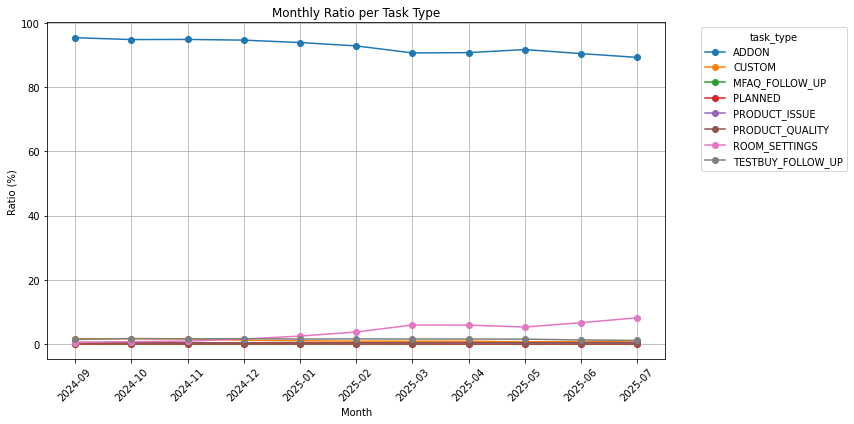

In [18]:
# Sort for proper chronological plotting
df_sorted = merged.sort_values("year_month").copy()

# Choose the categorical column to distinguish colours
CATEGORY_COL = "task_type"           # change to "merged_task" if needed

# --- Plot one line per CATEGORY_COL ---
plt.figure(figsize=(12, 6))
palette = sns.color_palette("tab10", n_colors=df_sorted[CATEGORY_COL].nunique())

for (cat_value, subdf), color in zip(df_sorted.groupby(CATEGORY_COL), palette):
    plt.plot(
        subdf["year_month"],
        subdf["ratio"],
        marker="o",
        linestyle="-",
        color=color,
        label=str(cat_value),
    )

plt.title("Monthly Ratio per Task Type")
plt.xlabel("Month")
plt.ylabel("Ratio (%)")
plt.grid(True)
plt.legend(title=CATEGORY_COL, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Section 2 : Overall validation


## 2.1 null distribution 


In [19]:
task_null_validation

,distinct_task,task_id_item_null,task_id_item_name_null,task_id_item_family_name_null,task_id_pa_no_null,task_id_pa_name_null,task_id_pra_no_null,task_id_pra_name_null,task_id_item_hfb_no_null,task_id_item_hfb_name_null,task_id_item_hfb_no_name_null,task_item_type_null,task_item_name_null,task_item_home_location_grid_code_null
0,10129503,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2.2 Overall distribution location by refill


In [13]:
item_refill_location.head()

,item_fill_location_department_name,number_of_different_grid_code,percentage
0,Home organisation,1027,1.756967
1,Markethall - Open the Wallet,654,1.118848
2,Activity Area,544,0.930662
3,Home textiles,807,1.380596
4,n/a,476,0.814329


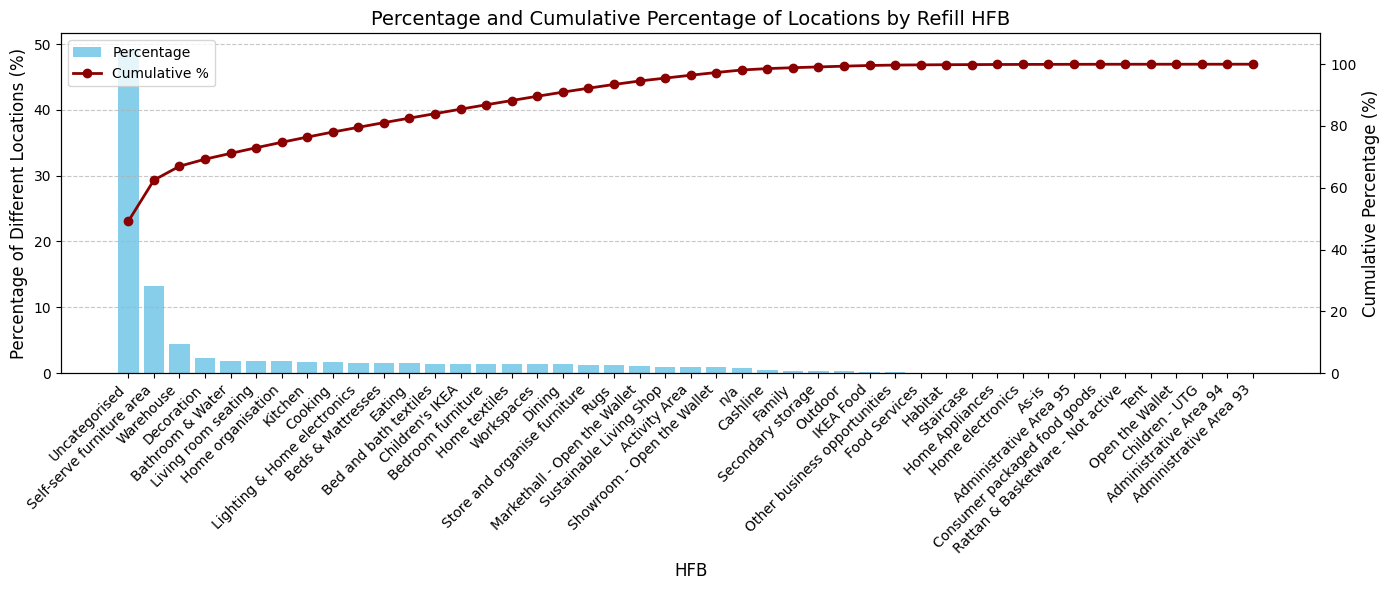

In [17]:
# Calculate total and percentage
total = item_refill_location['number_of_different_grid_code'].sum()
item_refill_location['percentage'] = (
    item_refill_location['number_of_different_grid_code'] / total
) * 100

# Sort by percentage in descending order
df_plot = item_refill_location.sort_values('percentage', ascending=False).reset_index(drop=True)

# Compute cumulative percentage
df_plot['cumulative_percentage'] = df_plot['percentage'].cumsum()

# Create figure and bar chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart (left axis)
bars = ax1.bar(
    df_plot['item_fill_location_department_name'],
    df_plot['percentage'],
    color='skyblue',
    label='Percentage'
)

# Customize X-axis
ax1.set_xticks(range(len(df_plot)))
ax1.set_xticklabels(df_plot['item_fill_location_department_name'], rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Percentage of Different Locations (%)', fontsize=12)
ax1.set_xlabel('HFB', fontsize=12)
ax1.set_title('Percentage and Cumulative Percentage of Locations by Refill HFB', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Create second Y-axis for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(
    df_plot['cumulative_percentage'],
    color='darkred',
    marker='o',
    linewidth=2,
    label='Cumulative %'
)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax2.set_ylim(0, 110)  # Make room for 100%+

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Final layout
plt.tight_layout()
plt.show()

In [16]:
item_refill_location_month.loc[(item_refill_location_month.year_month >='2024-09') & 
    (item_refill_location_month.year_month <'2025-09') & 
    (item_refill_location_month.item_fill_location_department_name	=='Uncategorised')].number_of_different_grid_code.sum()/item_refill_location_month.loc[(item_refill_location_month.year_month >='2024-09') & 
    (item_refill_location_month.year_month <'2025-09') ].number_of_different_grid_code.sum()

0.4058975376708261

            total_grid_codes  uncat_grid_codes  pct_uncat
year_month                                               
2023-09-01             23598             11051   46.83024
2023-10-01             24182             11279  46.642131
2023-11-01             25210             11902  47.211424
2023-12-01             24816             11546  46.526435
2024-01-01             25112             11585  46.133323
2024-02-01             25181             11669  46.340495
2024-03-01             25843             11993  46.407151
2024-04-01             26493             12286  46.374514
2024-05-01             26418             11893  45.018548
2024-06-01             26299             11921   45.32872
2024-07-01             27909             12559  44.999821
2024-08-01             28050             12480  44.491979
2024-09-01             27678             12220  44.150589
2024-10-01             29467             13171  44.697458
2024-11-01             29678             12913  43.510344
2024-12-01    

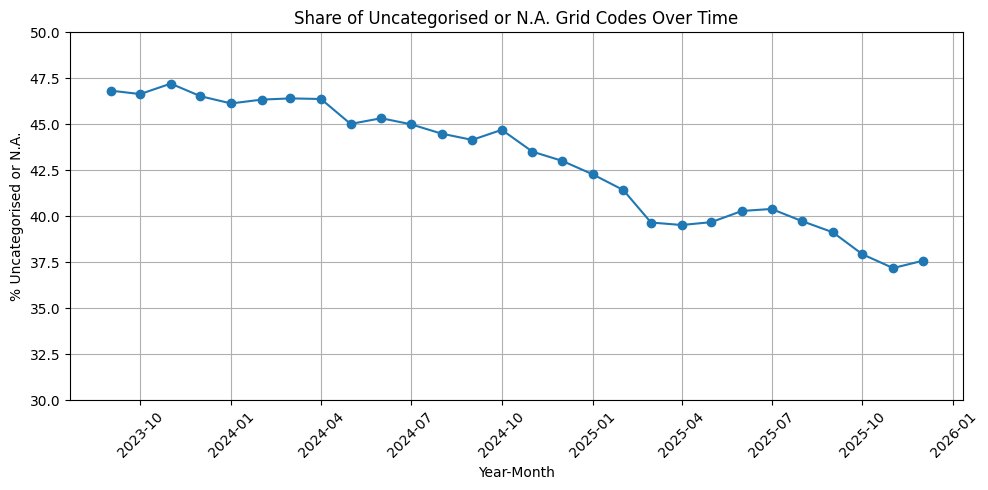

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Ensure year_month is a proper period or datetime (optional but useful for plotting) ---
df = item_refill_location_month.copy()
df['year_month'] = pd.to_datetime(df['year_month'], format='%Y-%m')

# --- Total per month ---
total_per_month = (
    df.groupby('year_month')['number_of_different_grid_code']
      .sum()
      .rename('total_grid_codes')
)

# --- Uncategorised / n.a per month ---
mask_uncat = df['item_fill_location_department_name'].str.strip().str.casefold().isin(
    ['uncategorised', 'n/a']
)

uncat_per_month = (
    df[mask_uncat]
      .groupby('year_month')['number_of_different_grid_code']
      .sum()
      .rename('uncat_grid_codes')
)

# --- Combine and compute percentage ---
summary = (
    pd.concat([total_per_month, uncat_per_month], axis=1)
      .fillna({'uncat_grid_codes': 0})  # if some months have no uncategorised/n.a.
)

summary['pct_uncat'] = summary['uncat_grid_codes'] / summary['total_grid_codes'] * 100

print(summary)

# --- Plot evolution ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(summary.index, summary['pct_uncat'], marker='o')
ax.set_xlabel('Year-Month')
ax.set_ylabel('% Uncategorised or N.A.')
ax.set_title('Share of Uncategorised or N.A. Grid Codes Over Time')
ax.grid(True)
ax.set_ylim(30, 50)  # <-- y-axis between 30 and 50
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [18]:
item_refill_location

,item_fill_location_department_name,number_of_different_grid_code,percentage
0,Home organisation,1027,1.756967
1,Markethall - Open the Wallet,654,1.118848
2,Activity Area,544,0.930662
3,Home textiles,807,1.380596
4,n/a,476,0.814329
5,Decoration,1336,2.285597
6,Habitat,32,0.054745
7,Consumer packaged food goods,7,0.011975
8,Administrative Area 95,9,0.015397
9,Tent,2,0.003422


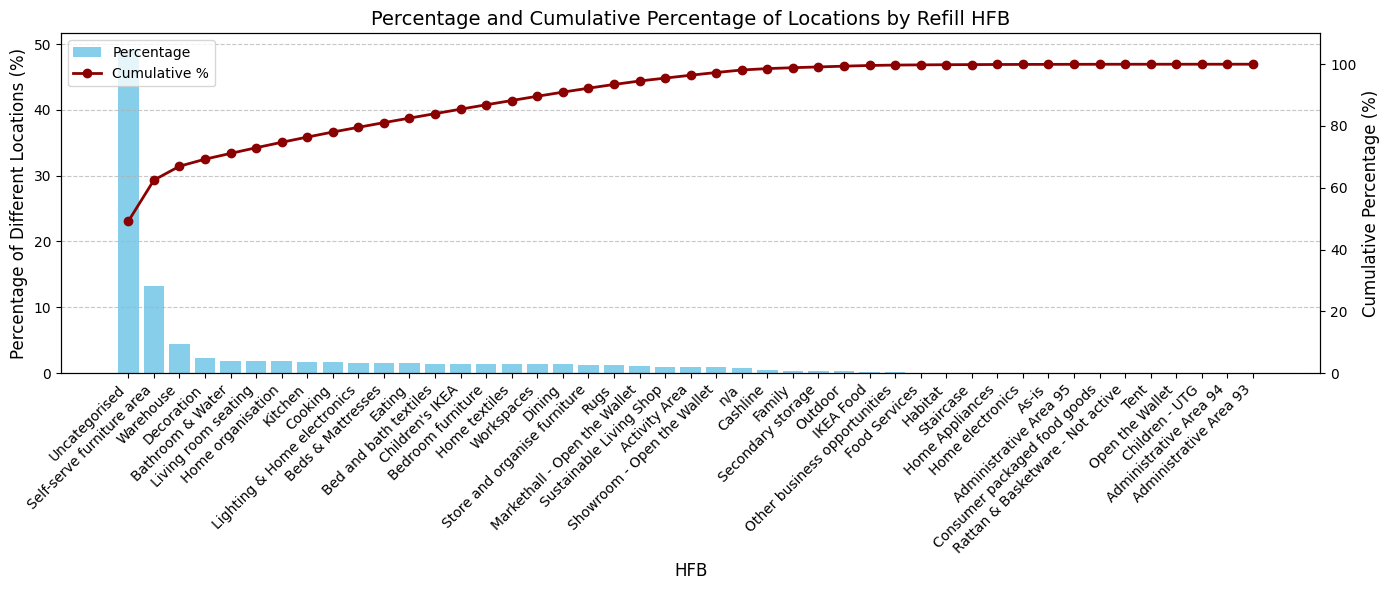

In [19]:
# Calculate total and percentage
total = item_refill_location['number_of_different_grid_code'].sum()
item_refill_location['percentage'] = (
    item_refill_location['number_of_different_grid_code'] / total
) * 100

# Sort by percentage in descending order
df_plot = item_refill_location.sort_values('percentage', ascending=False).reset_index(drop=True)

# Compute cumulative percentage
df_plot['cumulative_percentage'] = df_plot['percentage'].cumsum()

# Create figure and bar chart
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart (left axis)
bars = ax1.bar(
    df_plot['item_fill_location_department_name'],
    df_plot['percentage'],
    color='skyblue',
    label='Percentage'
)

# Customize X-axis
ax1.set_xticks(range(len(df_plot)))
ax1.set_xticklabels(df_plot['item_fill_location_department_name'], rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Percentage of Different Locations (%)', fontsize=12)
ax1.set_xlabel('HFB', fontsize=12)
ax1.set_title('Percentage and Cumulative Percentage of Locations by Refill HFB', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Create second Y-axis for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(
    df_plot['cumulative_percentage'],
    color='darkred',
    marker='o',
    linewidth=2,
    label='Cumulative %'
)
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12)
ax2.set_ylim(0, 110)  # Make room for 100%+

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# Final layout
plt.tight_layout()
plt.show()

## Section 2.3  Min max validation distribution


### 2.3.0 Number of task with refill value quantity


In [120]:
addons_refill_difference.head()

,task_created_date,year_month,task_id,store_no_name,item_no,item_name,item_price_eur,filled_qty,requested_qty,refilled_qty,picked_qty,difference_requested_refilled,difference_picked_refilled
0,2025-07-14,2025-07,bb3fec07-50b0-46c5-9aa5-d4e1bc1d6b0b,180 - IKEA Budapest - Örs vezér tere,20584096,SOLHETTA N2 GU10 345lm dimmable,2.187290500,70.000000000,70.000000000,70.000000000,70.000000000,0E-9,0E-9
1,2025-07-14,2025-07,02cb218c-fce3-4cba-bcf7-5f7b361ed5d9,411 - IKEA Washington - College Park,30238543,BUMERANG hanger natural 8-p,7.245603660,128.000000000,128.000000000,128.000000000,128.000000000,0E-9,0E-9
2,2025-07-14,2025-07,97dda711-9ba8-4232-8f45-a36cf3cdc2d0,165 - IKEA San Francisco - Emeryville,40291766,MOSSLANDA picture ledge 55 white,7.245603660,17.000000000,17.000000000,17.000000000,17.000000000,0E-9,0E-9
3,2025-07-14,2025-07,cf1bf6a8-30ad-4c7f-83a5-17dd6bb1b338,145 - IKEA Orlando,40300285,SKUBB shoe box 22x34x16 white 4-p US,9.059271660,19.000000000,19.000000000,19.000000000,19.000000000,0E-9,0E-9
4,2025-09-13,2025-09,cc3ab2b3-86a3-410b-b7eb-d29f157652ed,535 - IKEA Dallas - Grand Prairie,10375159,FEJKA artifi pttd plant 9 oregano,5.508907160,128.000000000,128.000000000,128.000000000,128.000000000,0E-9,0E-9


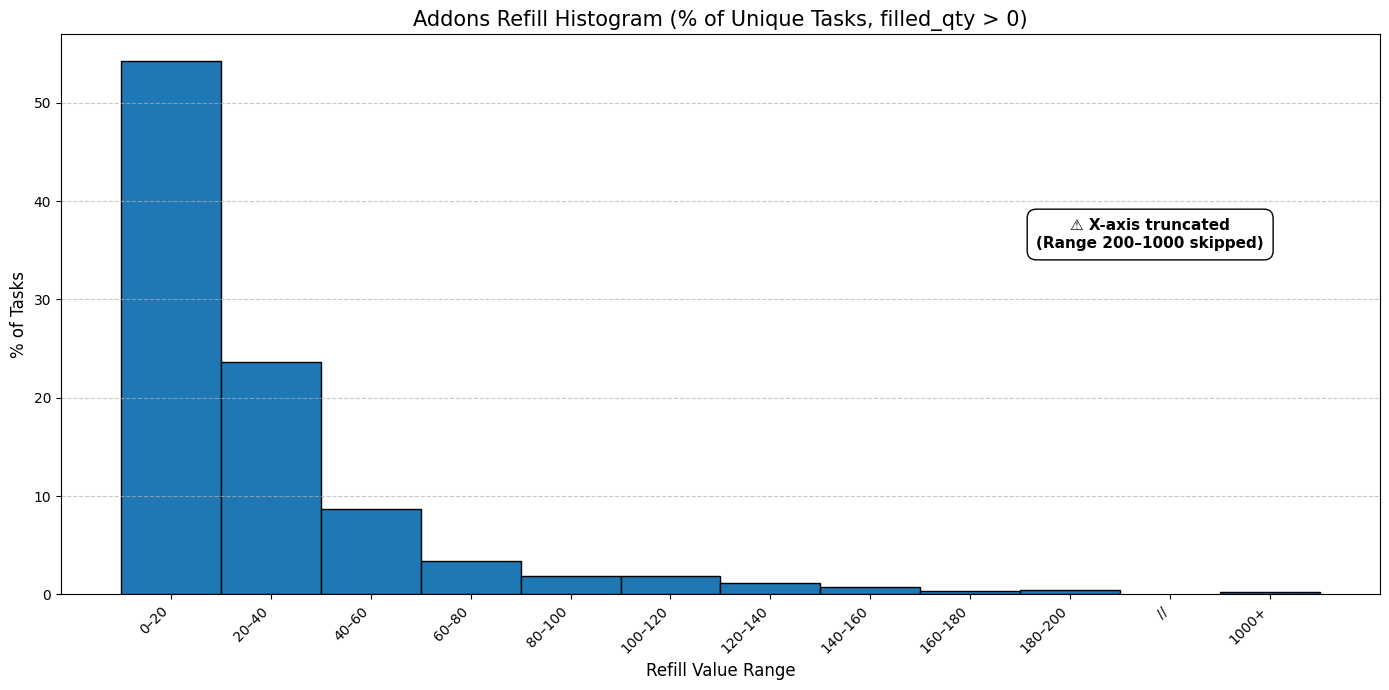

In [30]:
# Define bin edges: 0 to 1000 in steps of 20, then an overflow bin
bin_edges = np.append(np.arange(0, 1000, 20), [np.inf])

# Clean data: remove nulls, duplicates, and filled_qty == 0
df = (
    addons_refill_difference[['task_id', 'filled_qty']]
    .dropna()
    .drop_duplicates()
)
df = df[df['filled_qty'] > 0]

# Convert to float to avoid Decimal issues
data = df['filled_qty'].astype(float)

# Histogram with overflow bin
counts, bins = np.histogram(data, bins=bin_edges)
percentages = counts / counts.sum() * 100

# Generate bin labels
bin_labels = [f"{int(bins[i])}–{int(bins[i+1])}" if bins[i+1] != np.inf else "1000+" for i in range(len(bins)-1)]

# Show only first 10 bins (0–200) + break + overflow
num_bins_to_show = 10
bin_labels_to_show = bin_labels[:num_bins_to_show] + ['//', bin_labels[-1]]
percentages_to_show = list(percentages[:num_bins_to_show]) + [0, percentages[-1]]  # 0 for the break bar

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(bin_labels_to_show, percentages_to_show, width=1, edgecolor='black', align='center')

# Make break bar invisible
bars[num_bins_to_show].set_color('white')
bars[num_bins_to_show].set_edgecolor('white')

# Add visible "X-axis truncated" label
plt.text(
    num_bins_to_show - 0.2,
    max(percentages_to_show) * 0.65,
    '⚠ X-axis truncated\n(Range 200–1000 skipped)',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='black',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Rotate X-axis labels
plt.xticks(rotation=45, ha='right')

# Compute statistics
min_val = data.min()
max_val = data.max()
mean_val = data.mean()
median_val = data.median()
std_val = data.std()

# Outlier detection with IQR
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outliers = data[data > outlier_threshold]
num_outliers = len(outliers)
outlier_pct = num_outliers / len(data) * 100

# Add statistics box (more spacious and aligned)
stats_text = (
    f" Stats:\n"
    f"• Min: {min_val:.0f}    Max: {max_val:.0f}\n"
    f"• Mean: {mean_val:.1f}    Median: {median_val:.1f}\n"
    f"• Std Dev: {std_val:.1f}\n"
    f"• Outliers (> {outlier_threshold:.0f}): {num_outliers} ({outlier_pct:.1f}%)"
)
#plt.text(
  #  0.98, 0.95, stats_text,
   # transform=plt.gca().transAxes,
  #  fontsize=11,
  #  verticalalignment='top',
  #  horizontalalignment='right',
 #   bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
#)

# Titles and final styling
plt.title('Addons Refill Histogram (% of Unique Tasks, filled_qty > 0)', fontsize=15)
plt.xlabel('Refill Value Range', fontsize=12)
plt.ylabel('% of Tasks', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/var/folders/69/q_vmc6ns6_v503hjpfz65h8r0000gp/T/ipykernel_55613/4202967591.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = (task_qty.groupby(["year_month", "bin"])


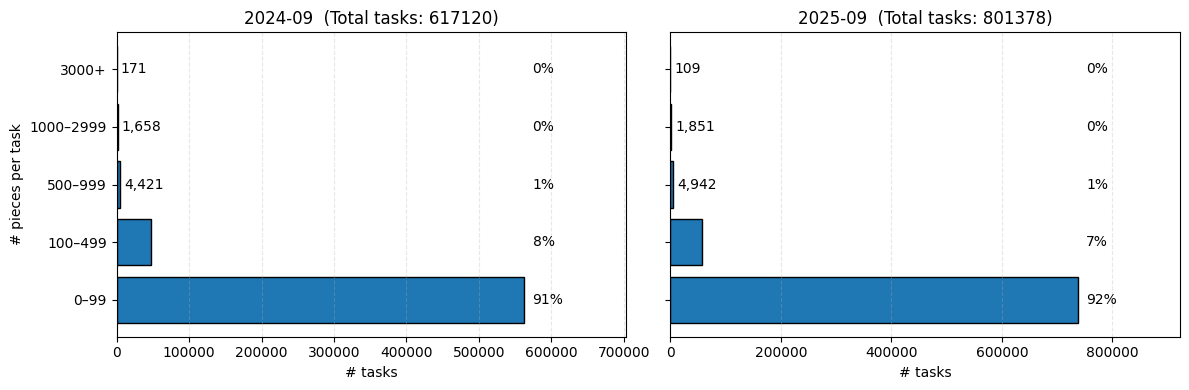

In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

m1, m2 = "2024-09", "2025-09"

df = addons_refill_difference.copy()
df["year_month"] = df["year_month"].astype(str)

df = df[df["year_month"].isin([m1, m2])]
df = df[["year_month", "task_id", "filled_qty"]].dropna()
df["filled_qty"] = df["filled_qty"].astype(float)
df = df[df["filled_qty"] > 0]

task_qty = df.groupby(["year_month", "task_id"], as_index=False)["filled_qty"].sum()

bins   = [0, 100, 500, 1000, 3000, np.inf]
labels = ["0–99", "100–499", "500–999", "1000–2999", "3000+"]

task_qty["bin"] = pd.cut(task_qty["filled_qty"], bins=bins, labels=labels, right=False)

summary = (task_qty.groupby(["year_month", "bin"])
                  .size()
                  .reset_index(name="tasks"))

tot = summary.groupby("year_month")["tasks"].sum().rename("total_tasks")
summary = summary.merge(tot, on="year_month")
summary["pct"] = 100 * summary["tasks"] / summary["total_tasks"]

summary = (summary.set_index(["year_month", "bin"])
                  .reindex(pd.MultiIndex.from_product([[m1, m2], labels], names=["year_month","bin"]))
                  .fillna(0)
                  .reset_index())

# bins where you want to show counts close to the bar
show_count_bins = {"500–999", "1000–2999", "3000+"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, month in zip(axes, [m1, m2]):
    s = summary[summary["year_month"] == month].copy()
    s["bin"] = pd.Categorical(s["bin"], categories=labels, ordered=True)
    s = s.sort_values("bin", ascending=True)

    ax.barh(s["bin"], s["tasks"], edgecolor="black")
    ax.set_title(f"{month}  (Total tasks: {int(s['total_tasks'].max())})")
    ax.set_xlabel("# tasks")
    ax.grid(axis="x", linestyle="--", alpha=0.3)

    xmax = s["tasks"].max() if s["tasks"].max() > 0 else 1

    for b, tasks, pct in zip(s["bin"], s["tasks"], s["pct"]):
        b = str(b)

        # % on the far right
        ax.text(xmax * 1.02, b, f"{pct:.0f}%", va="center", ha="left")

        # count near the bar for big-scale bins
        if b in show_count_bins and tasks > 0:
            ax.text(tasks + xmax * 0.01, b, f"{int(tasks):,}", va="center", ha="left")

    ax.set_xlim(0, xmax * 1.25)

axes[0].set_ylabel("# pieces per task")
plt.tight_layout()
plt.show()


### 2.3.1 Refill qty and requested difference 

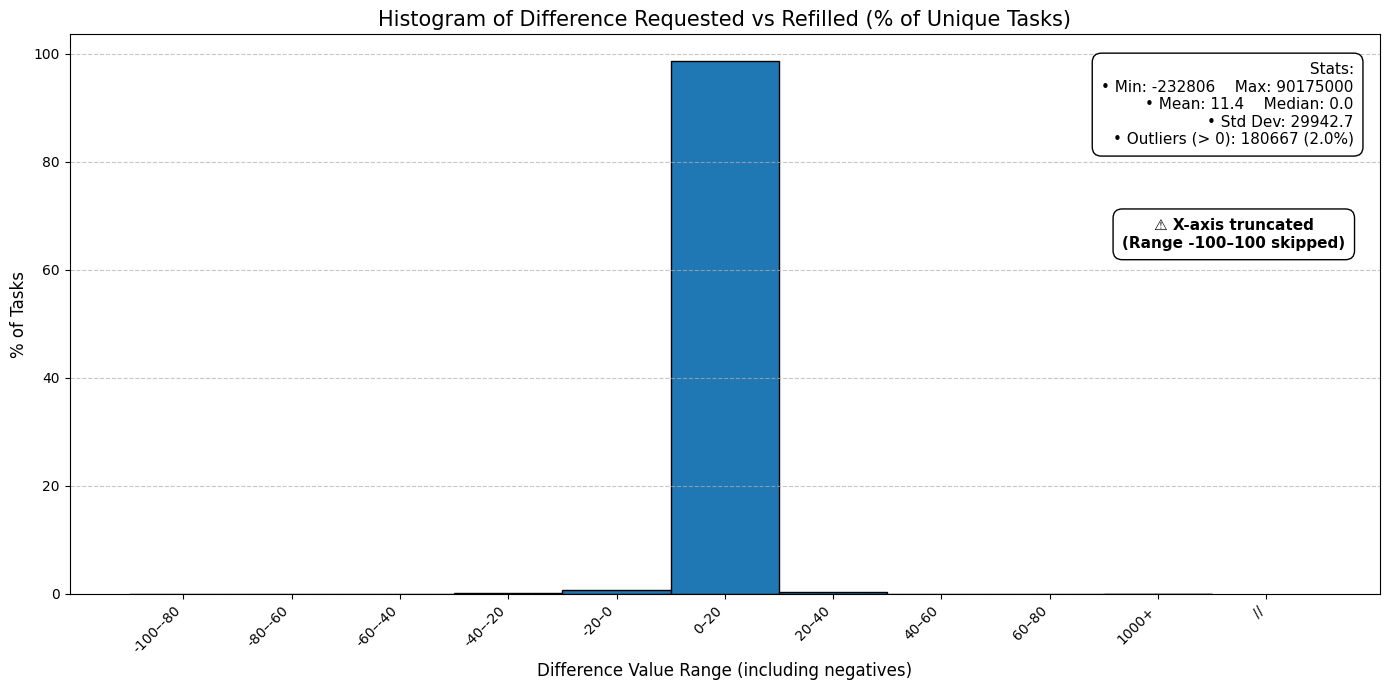

In [13]:
# Define bin edges: from -500 to 1000 in steps of 20, then overflow
bin_edges = np.append(np.arange(-100, 100, 20), [np.inf])

# Clean data: remove nulls, duplicates only
df = (
    addons_refill_difference[['task_id', 'difference_requested_refilled']]
    .dropna()
    .drop_duplicates()
)

# Convert to float (for Decimal safety)
data = df['difference_requested_refilled'].astype(float)

# Histogram
counts, bins = np.histogram(data, bins=bin_edges)
percentages = counts / counts.sum() * 100

# Create bin labels
bin_labels = [
    f"{int(bins[i])}–{int(bins[i+1])}" if bins[i+1] != np.inf else "1000+"
    for i in range(len(bins) - 1)
]

# Determine indices to show before truncation (up to 200) and final bin (1000+)
cutoff_index = np.where(bins >= 200)[0][0]  # first bin starting at >= 200
overflow_index = len(bin_labels) - 1        # last bin (1000+)

# Compose labels and data to show (truncate middle)
bin_labels_to_show = bin_labels[:cutoff_index] + ['//'] + [bin_labels[overflow_index]]
percentages_to_show = list(percentages[:cutoff_index]) + [0] + [percentages[overflow_index]]

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(bin_labels_to_show, percentages_to_show, width=1, edgecolor='black', align='center')

# Make break bar invisible
bars[cutoff_index].set_color('white')
bars[cutoff_index].set_edgecolor('white')

# Add visible truncation label
plt.text(
    cutoff_index - 0.3,
    max(percentages_to_show) * 0.65,
    '⚠ X-axis truncated\n(Range -100–100 skipped)',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='black',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Rotate X-axis labels
plt.xticks(rotation=45, ha='right')

# Compute statistics
min_val = data.min()
max_val = data.max()
mean_val = data.mean()
median_val = data.median()
std_val = data.std()

# Outlier detection (IQR on absolute values)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outliers = data[data > outlier_threshold]
num_outliers = len(outliers)
outlier_pct = num_outliers / len(data) * 100

# Stats box
stats_text = (
    f" Stats:\n"
    f"• Min: {min_val:.0f}    Max: {max_val:.0f}\n"
    f"• Mean: {mean_val:.1f}    Median: {median_val:.1f}\n"
    f"• Std Dev: {std_val:.1f}\n"
    f"• Outliers (> {outlier_threshold:.0f}): {num_outliers} ({outlier_pct:.1f}%)"
)
plt.text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Final formatting
plt.title('Histogram of Difference Requested vs Refilled (% of Unique Tasks)', fontsize=15)
plt.xlabel('Difference Value Range (including negatives)', fontsize=12)
plt.ylabel('% of Tasks', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
addons_refill_difference[['task_id', 'difference_requested_refilled']].min()

task_id                          00000478-6020-44c3-bd53-325c85e67604
difference_requested_refilled                       -232806.000000000
dtype: object

### 2.3.2 Picked qty and refill difference

/var/folders/y0/zlfn4n2d0n70dbtgn_63gp0xr3ydtm/T/ipykernel_27372/2286909357.py:93: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  plt.tight_layout()
/Users/salov/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


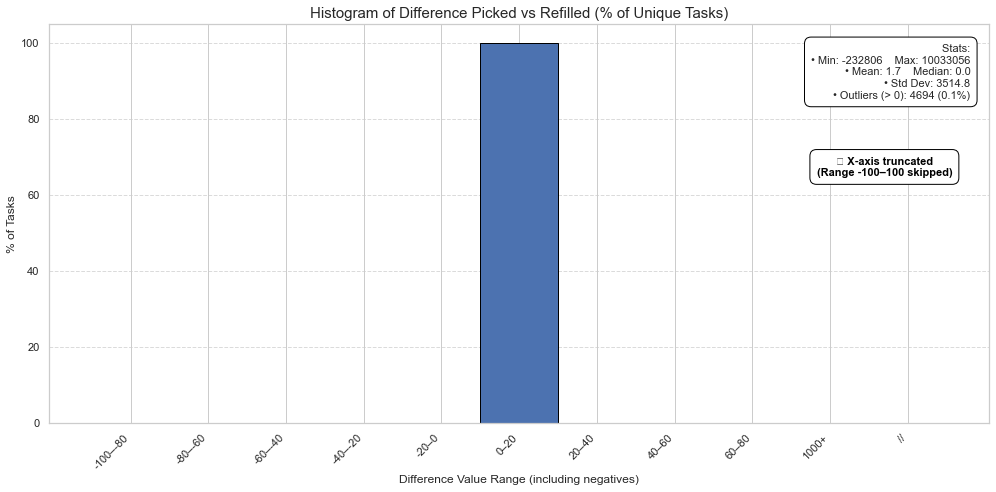

In [83]:
# Define bin edges: from -500 to 1000 in steps of 20, then overflow
bin_edges = np.append(np.arange(-100, 100, 20), [np.inf])

# Clean data: remove nulls, duplicates only
df = (
    addons_refill_difference[['task_id', 'difference_picked_refilled']]
    .dropna()
    .drop_duplicates()
)

# Convert to float (for Decimal safety)
data = df['difference_picked_refilled'].astype(float)

# Histogram
counts, bins = np.histogram(data, bins=bin_edges)
percentages = counts / counts.sum() * 100

# Create bin labels
bin_labels = [
    f"{int(bins[i])}–{int(bins[i+1])}" if bins[i+1] != np.inf else "1000+"
    for i in range(len(bins) - 1)
]

# Determine indices to show before truncation (up to 200) and final bin (1000+)
cutoff_index = np.where(bins >= 200)[0][0]  # first bin starting at >= 200
overflow_index = len(bin_labels) - 1        # last bin (1000+)

# Compose labels and data to show (truncate middle)
bin_labels_to_show = bin_labels[:cutoff_index] + ['//'] + [bin_labels[overflow_index]]
percentages_to_show = list(percentages[:cutoff_index]) + [0] + [percentages[overflow_index]]

# Plot
plt.figure(figsize=(14, 7))
bars = plt.bar(bin_labels_to_show, percentages_to_show, width=1, edgecolor='black', align='center')

# Make break bar invisible
bars[cutoff_index].set_color('white')
bars[cutoff_index].set_edgecolor('white')

# Add visible truncation label
plt.text(
    cutoff_index - 0.3,
    max(percentages_to_show) * 0.65,
    '⚠ X-axis truncated\n(Range -100–100 skipped)',
    ha='center',
    fontsize=11,
    fontweight='bold',
    color='black',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Rotate X-axis labels
plt.xticks(rotation=45, ha='right')

# Compute statistics
min_val = data.min()
max_val = data.max()
mean_val = data.mean()
median_val = data.median()
std_val = data.std()

# Outlier detection (IQR on absolute values)
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outlier_threshold = Q3 + 1.5 * IQR
outliers = data[data > outlier_threshold]
num_outliers = len(outliers)
outlier_pct = num_outliers / len(data) * 100

# Stats box
stats_text = (
    f" Stats:\n"
    f"• Min: {min_val:.0f}    Max: {max_val:.0f}\n"
    f"• Mean: {mean_val:.1f}    Median: {median_val:.1f}\n"
    f"• Std Dev: {std_val:.1f}\n"
    f"• Outliers (> {outlier_threshold:.0f}): {num_outliers} ({outlier_pct:.1f}%)"
)
plt.text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.6')
)

# Final formatting
plt.title('Histogram of Difference Picked vs Refilled (% of Unique Tasks)', fontsize=15)
plt.xlabel('Difference Value Range (including negatives)', fontsize=12)
plt.ylabel('% of Tasks', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2.3.3 Min max distribution

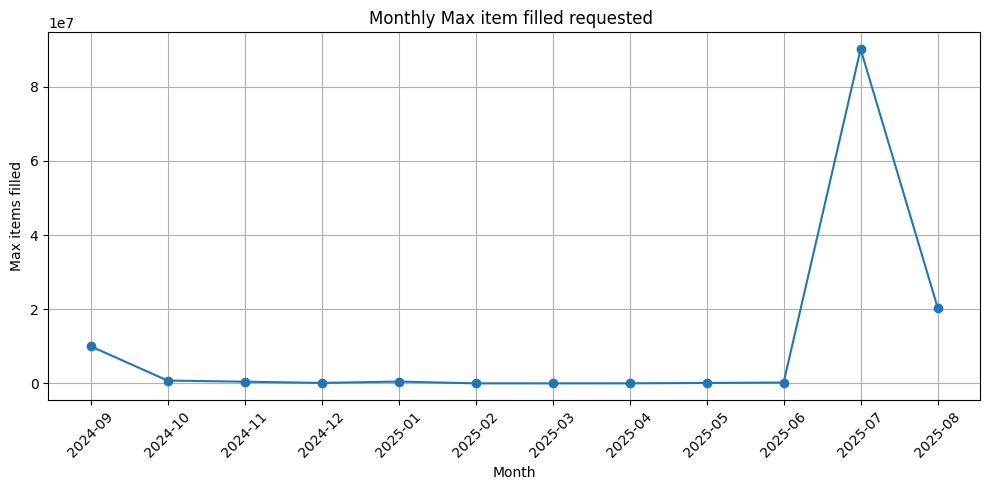

In [15]:
#trend with the max mothly requested
grouped_month_max=addons_refill_difference.groupby(['year_month']).agg({
           'requested_qty' : ['max'],
        }).reset_index()



grouped_month_max.columns = grouped_month_max.columns.map('_'.join)
grouped_month_max.rename(columns = {
                                'year_month_' : 'year_month',
                      'requested_qty_max_' : 'requested_qty_max'
                         }, inplace = True)



# Ordena por fecha por si acaso
grouped_month_max = grouped_month_max.sort_values('year_month')

grouped_month_max['year_month']=grouped_month_max['year_month'].astype(str)
# Plot
plt.figure(figsize=(10, 5))
plt.plot(grouped_month_max['year_month'], grouped_month_max['requested_qty_max'], marker='o', linestyle='-')
plt.title('Monthly Max item filled requested ')
plt.xlabel('Month')
plt.ylabel('Max items filled')

#plt.ylim(90, 100)  

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

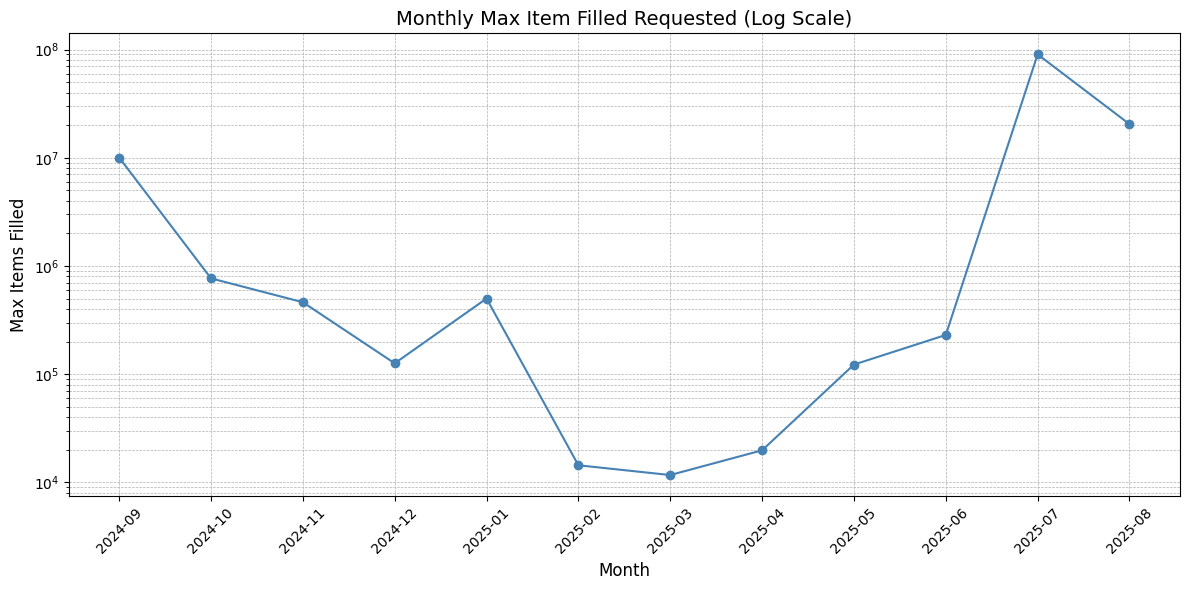

In [16]:
import matplotlib.pyplot as plt

# Ordenar por fecha por si acaso
grouped_month_max = grouped_month_max.sort_values('year_month')
grouped_month_max['year_month'] = grouped_month_max['year_month'].astype(str)

# Crear la figura
plt.figure(figsize=(12, 6))
plt.plot(
    grouped_month_max['year_month'],
    grouped_month_max['requested_qty_max'],
    marker='o', linestyle='-', color='steelblue'
)

# Título y etiquetas
plt.title('Monthly Max Item Filled Requested (Log Scale)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Max Items Filled', fontsize=12)

# Escala logarítmica en el eje Y
plt.yscale('log')

# Ajustes estéticos
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

In [17]:
grouped_month_max.tail()

,year_month,requested_qty_max
7,2025-04,19803.000000000
8,2025-05,122640.000000000
9,2025-06,230400.000000000
10,2025-07,90175000.000000000
11,2025-08,20434832.000000000


In [19]:
addons_refill_difference.loc[(addons_refill_difference.year_month=='2025-08') & 
                             (addons_refill_difference.requested_qty > 10000)
                            ]

,task_created_date,year_month,task_id,store_no_name,item_no,item_name,item_price_eur,filled_qty,requested_qty,refilled_qty,picked_qty,difference_requested_refilled,difference_picked_refilled
102486,2025-08-08,2025-08,585e0635-5a3c-4ee8-8eb0-2245ce494125,422 - IKEA Vantaa,90551498,UPPÅTVIND filter f part removal,5.000000000,20434832.000000000,20434832.000000000,20434832.000000000,20434832.000000000,0E-9,0E-9
266047,2025-08-04,2025-08,12e8992b-9fa5-4e79-9bac-5cf4f2a4a6da,028 - IKEA Oregon - Portland,60581034,ALLEMANSRÄTTEN savoury sauce mix 28 g US,1.532549460,18432.000000000,18432.000000000,18432.000000000,18432.000000000,0E-9,0E-9
667378,2025-08-03,2025-08,52ffb4cf-c445-4def-8c55-106838f93c1d,921 - IKEA New York - Brooklyn,17228340,FRAKTA carrier bag large 55x37x35 cm/71 l blue,0.897765660,24000.000000000,24000.000000000,24000.000000000,24000.000000000,0E-9,0E-9
905492,2025-08-24,2025-08,cb6744b1-d4ca-445c-a12c-a22edaf0c705,263 - IKEA Nottingham,10572942,SYLT LINGON lingonberry spread 400 g organic UK,2.859400000,44444.000000000,44444.000000000,44444.000000000,44444.000000000,0E-9,0E-9
910121,2025-08-02,2025-08,26087700-b55b-4f0d-8ea1-8124b3292c35,157 - IKEA Sacramento - West Sacramento,00531546,CHOKLAD MÖRK drk choco tblt 100g RAC US,1.804599660,531546.000000000,531546.000000000,531546.000000000,531546.000000000,0E-9,0E-9
1098592,2025-08-20,2025-08,30704b9e-f974-47ae-b14a-ad2f7f229257,261 - IKEA Leeds,70354309,ALLEMANSRÄTTEN mix for cream sauce 28g,1.258136000,12672.000000000,12672.000000000,12672.000000000,12672.000000000,0E-9,0E-9


In [22]:
addons_refill_difference

,task_created_date,year_month,task_id,store_no_name,item_no,item_name,item_price_eur,filled_qty,requested_qty,refilled_qty,picked_qty,difference_requested_refilled,difference_picked_refilled
0,2025-04-30,2025-04,b1d40c56-6ae4-4428-b6ac-d58f0fd0ff58,189 - IKEA Fukuoka - Shingu,80451055,NYSKÖLJD dish drying mat 44x36 dark grey AP,1.886690000,66.000000000,66.000000000,66.000000000,66.000000000,0E-9,0E-9
1,2025-04-30,2025-04,54543674-1aee-481d-acbd-f3b0e00b97f9,291 - IKEA Zürich - Dietlikon,00428549,SKUBB N box s6 white,10.529488000,116.000000000,116.000000000,116.000000000,116.000000000,0E-9,0E-9
2,2025-04-30,2025-04,3fdfd290-4ad7-468a-995c-ac915a6eeceb,242 - IKEA Toulouse - Roques,10238539,BUMERANG hanger natural 8-p MA1,4.990000000,256.000000000,256.000000000,256.000000000,256.000000000,0E-9,0E-9
3,2024-11-04,2024-11,PjVGxgpb2TvgoCeMFFCr,174 - IKEA Kassel,10443974,DRÖNA N box 33x38x33 dark grey,4.990000000,204.000000000,204.000000000,204.000000000,204.000000000,0E-9,0E-9
4,2024-11-03,2024-11,OpcbSCJv4wRvrIVmPqDK,343 - IKEA München - Taufkirchen,20434832,MURVEL shoe org 14x14x24 grey,1.000000000,150.000000000,150.000000000,150.000000000,150.000000000,0E-9,0E-9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9182670,2024-11-08,2024-11,PiKQJieYm4bG3LOUnzBy,210 - IKEA Chicago - Schaumburg,10269818,SLÅN pllw softer Standard US,3.618267660,5.000000000,5.000000000,5.000000000,5.000000000,0E-9,0E-9
9182671,2024-11-08,2024-11,53suoYBnErGAgVAtTtYf,359 - IKEA Tokyo - Tachikawa,30550703,INNER cush pad 50x50 white/firm AP,3.155000000,5.000000000,5.000000000,5.000000000,5.000000000,0E-9,0E-9
9182672,2025-05-31,2025-05,4a398993-fe70-496b-8091-eddcca047b4b,094 - IKEA Copenhagen - Tåstrup,00552020,ÖVNING N multifunc ergo ftrst,17.324442000,5.000000000,5.000000000,5.000000000,5.000000000,0E-9,0E-9
9182673,2025-05-31,2025-05,27234b56-9b58-4e17-aef6-77091d12477d,401 - IKEA Hangzhou,60482449,DVALA fitt sheet 150x200 light grey AP,10.410858480,5.000000000,5.000000000,5.000000000,5.000000000,0E-9,0E-9


In [24]:
grouped_month_gt3000

,year_month,item_no_count
0,2024-09,191
1,2024-10,199
2,2024-11,170
3,2024-12,140
4,2025-01,143
5,2025-02,93
6,2025-03,127
7,2025-04,92
8,2025-05,105
9,2025-06,137


   year_month  item_no_count_ge3000  item_no_count_total  pct_ge3000
0     2024-09                   191               617113    0.030951
1     2024-10                   199               660869    0.030112
2     2024-11                   170               716944    0.023712
3     2024-12                   140               721553    0.019403
4     2025-01                   143               776847    0.018408
5     2025-02                    93               718324    0.012947
6     2025-03                   127               810464    0.015670
7     2025-04                    92               773773    0.011890
8     2025-05                   105               804199    0.013056
9     2025-06                   137               731455    0.018730
10    2025-07                   160               875353    0.018278
11    2025-08                   135               975781    0.013835


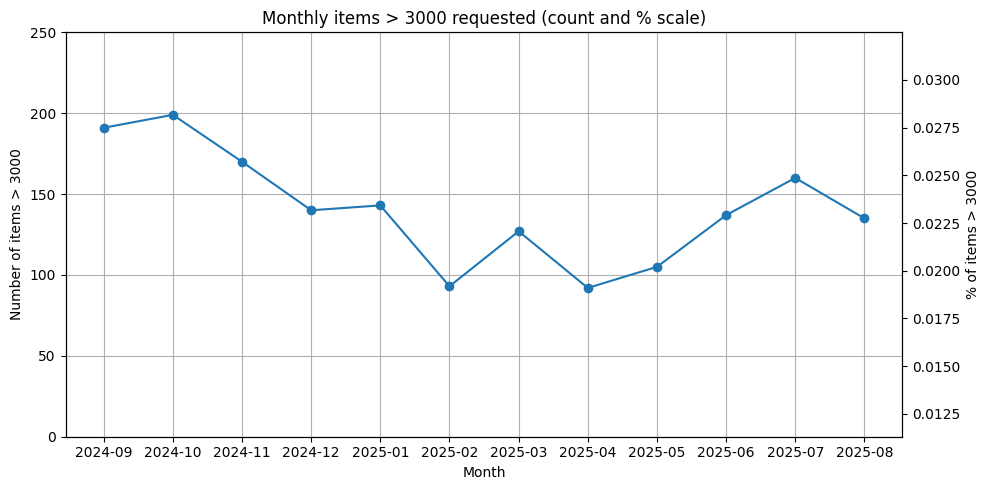

In [36]:
import matplotlib.pyplot as plt

# ---- 1) Items >= 3000 per month ----
grouped_month_gt3000 = (
    addons_refill_difference
    .loc[addons_refill_difference.requested_qty >= 3000]
    .groupby(['year_month'])
    .agg({'item_no': ['count']})
    .reset_index()
)

grouped_month_gt3000.columns = grouped_month_gt3000.columns.map('_'.join)
grouped_month_gt3000.rename(columns={
    'year_month_': 'year_month',
    'item_no_count': 'item_no_count_ge3000'
}, inplace=True)

# ---- 2) Total items per month (for the %) ----
grouped_month_total = (
    addons_refill_difference
    .groupby(['year_month'])
    .agg({'item_no': ['count']})
    .reset_index()
)

grouped_month_total.columns = grouped_month_total.columns.map('_'.join)
grouped_month_total.rename(columns={
    'year_month_': 'year_month',
    'item_no_count': 'item_no_count_total'
}, inplace=True)

# ---- 3) Merge and compute percentage (0–100) ----
df_plot = grouped_month_gt3000.merge(grouped_month_total, on='year_month', how='left')
df_plot = df_plot.sort_values('year_month')
df_plot['year_month'] = df_plot['year_month'].astype(str)

df_plot['pct_ge3000'] = (
    df_plot['item_no_count_ge3000'] / df_plot['item_no_count_total'] * 100.0
)

# (optional) quick sanity check
print(df_plot[['year_month', 'item_no_count_ge3000',
               'item_no_count_total', 'pct_ge3000']])

# ---- 4) Plot: left axis = count, right axis = % scale (no second line) ----
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left y-axis: number of items > 3000 (single line)
ax1.plot(
    df_plot['year_month'],
    df_plot['item_no_count_ge3000'],
    marker='o',
    linestyle='-'
)
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of items > 3000')
ax1.set_ylim(0, 250)
ax1.grid(True)

# Right y-axis: % of items > 3000 (scale only)
ax2 = ax1.twinx()
ax2.set_ylabel('% of items > 3000')

min_pct = df_plot['pct_ge3000'].min()
max_pct = df_plot['pct_ge3000'].max()
ax2.set_ylim(min_pct * 0.95, max_pct * 1.05)  # no 0.000 unless it's really 0

plt.xticks(rotation=45)
plt.title('Monthly items > 3000 requested (count and % scale)')
fig.tight_layout()
plt.show()


## 2.4 Time:  between test, completed task


In [117]:
addons_time_between_tasks

,task_id,difference_in_seconds
0,VzCrS9mItO6T3wF7Lg9z,3
1,TQfytRpVtA5yIJmQ646x,10
2,uCUzSDlzSOXADadjHGL9,13
3,Ef14qdTvRDN6TDFMxx70,17
4,6B09QLw44Cw6xoME7OCT,120
...,...,...
10128879,d9208390-4c69-42b7-a689-7e92e3578c07,14
10128880,59138d8a-c4a9-4c4a-baa3-3f19a28f3aa3,11
10128881,8c046a01-ade0-4e98-84d1-dd7a5670998b,11
10128882,bd9e21c2-de8e-4aee-b44d-4c1e679906d9,13


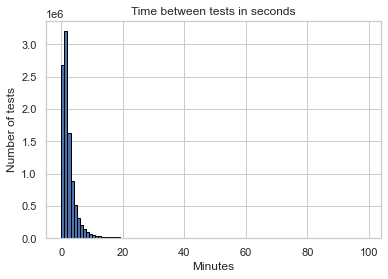

In [124]:
import matplotlib.pyplot as plt
import numpy as np

#Number of bins
bin_edges=np.arange(0,100,1)
# Crear el histograma
plt.hist(addons_time_between_tasks['difference_in_seconds'], bins=bin_edges, edgecolor='black')

# Añadir títulos y etiquetas
plt.title('Time between tests in seconds')
plt.xlabel('Minutes')
plt.ylabel('Number of tests')

# Mostrar el histograma
plt.show()

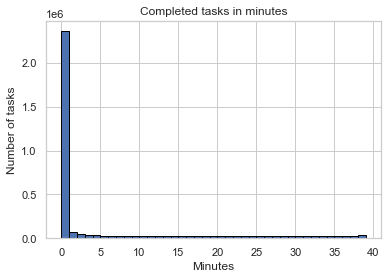

In [126]:
import matplotlib.pyplot as plt
import numpy as np

#Number of bins
bin_edges=np.arange(0,40,1)
# Crear el histograma
plt.hist(created_completed_June24['lag_created_completed_minute'], bins=bin_edges, edgecolor='black')

# Añadir títulos y etiquetas
plt.title('Completed tasks in minutes')
plt.xlabel('Minutes')
plt.ylabel('Number of tasks')

# Mostrar el histograma
plt.show()

## 2.5 Validation valid grid code

## 2.5.1 simple location validation

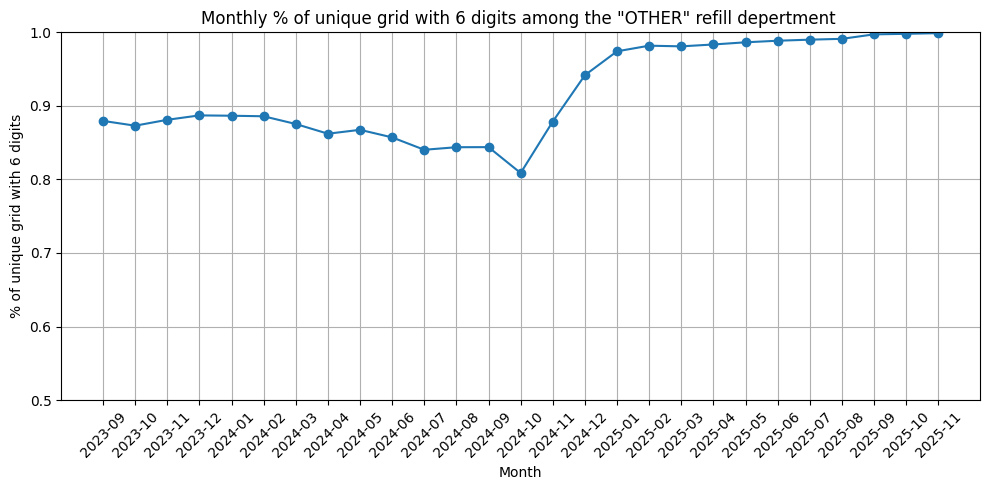

In [66]:
# Ordena por fecha por si acaso
task_grid_validation = task_grid_validation.sort_values('year_month')

task_grid_validation['year_month']=task_grid_validation['year_month'].astype(str)
# Plot
plt.figure(figsize=(10, 5))
plt.plot(task_grid_validation['year_month'], task_grid_validation['perc_correct_grid_length'], marker='o', linestyle='-')
plt.title('Monthly % of unique grid with 6 digits among the "OTHER" refill depertment ')
plt.xlabel('Month')
plt.ylabel('% of unique grid with 6 digits')

plt.ylim(0.5, 1.00)  

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2.5.2 validation grid code

In [92]:
task_location.store_no.nunique()

412

In [104]:
grouped_month=task_location.groupby(['iso_month_no']).agg({
           'total_grid_codes' : ['sum'],
           'total_valid_grid_codes' : ['sum']
        }).reset_index()


grouped_month.columns = grouped_month.columns.map('_'.join)
grouped_month.rename(columns = {
                                'iso_month_no_' : 'iso_month_no',
                      'total_grid_codes_sum' : 'total_grid_codes',
                      'total_valid_grid_codes_sum' : 'total_valid_grid_codes'
                         }, inplace = True)
grouped_month['ratio_valid']= 100.*grouped_month['total_valid_grid_codes'] /grouped_month['total_grid_codes'] 
grouped_month.head()

,iso_month_no,total_grid_codes,total_valid_grid_codes,ratio_valid
0,202309,203544,175192,86.070825
1,202310,211554,180667,85.399945
2,202311,219259,186512,85.064695
3,202312,212749,180503,84.843172
4,202401,214928,183731,85.484907


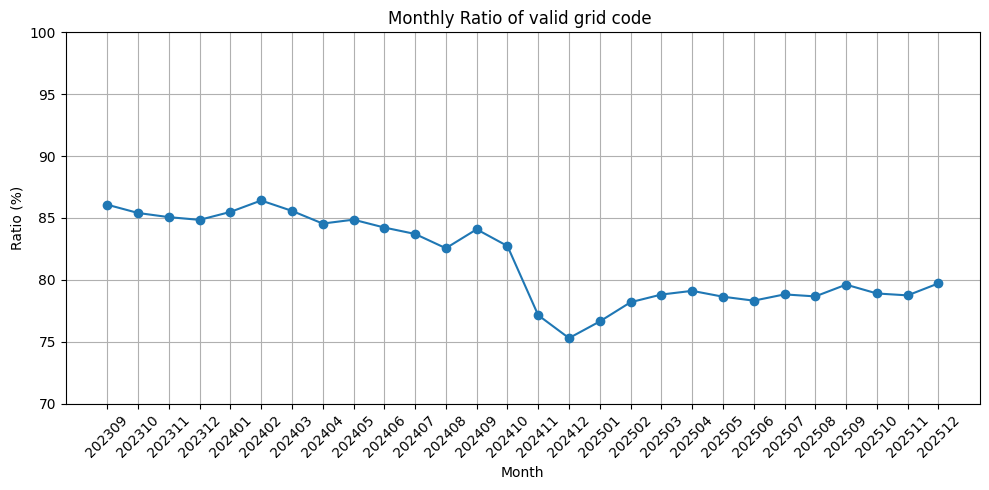

In [105]:

# Ordena por fecha por si acaso
grouped_month = grouped_month.sort_values('iso_month_no')

grouped_month['iso_month_no']=grouped_month['iso_month_no'].astype(str)
# Plot
plt.figure(figsize=(10, 5))
plt.plot(grouped_month['iso_month_no'], grouped_month['ratio_valid'], marker='o', linestyle='-')
plt.title('Monthly Ratio of valid grid code ')
plt.xlabel('Month')
plt.ylabel('Ratio (%)')

plt.ylim(70, 100)  

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## just 274

In [100]:
task_location

,ikea_week_no,iso_month_no,store_no,total_grid_codes,total_valid_grid_codes
0,202335,202309,379,100,91
1,202335,202309,467,14,12
2,202335,202309,038,90,87
3,202335,202309,272,42,35
4,202335,202309,042,74,66
...,...,...,...,...,...
50674,202601,202512,156,69,59
50675,202601,202512,211,65,59
50676,202601,202512,148,95,90
50677,202601,202512,226,71,66


In [97]:
grouped_month_store=task_location.loc[task_location.store_no=='274'].groupby(['iso_month_no']).agg({
           'total_grid_codes' : ['sum'],
           'total_valid_grid_codes' : ['sum']
        }).reset_index()


grouped_month_store.columns = grouped_month_store.columns.map('_'.join)
grouped_month_store.rename(columns = {
                                'iso_month_no_' : 'iso_month_no',
                      'total_grid_codes_sum' : 'total_grid_codes',
                      'total_valid_grid_codes_sum' : 'total_valid_grid_codes'
                         }, inplace = True)
grouped_month_store['ratio_valid']= 100.*grouped_month_store['total_valid_grid_codes'] /grouped_month_store['total_grid_codes'] 
grouped_month_store.head()

,iso_month_no,total_grid_codes,total_valid_grid_codes,ratio_valid
0,202309,559,479,85.68873
1,202310,717,602,83.960948
2,202311,631,528,83.676704
3,202312,655,557,85.038168
4,202401,615,549,89.268293


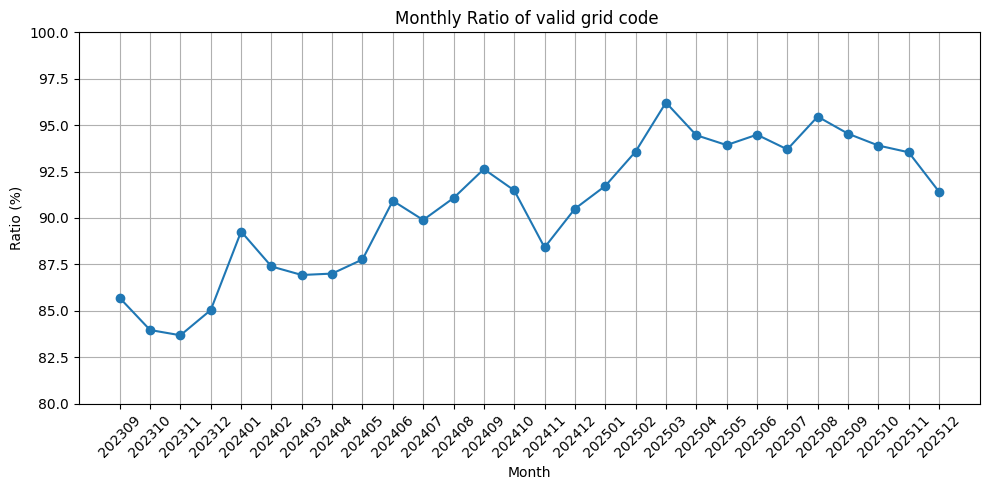

In [98]:

# Ordena por fecha por si acaso
grouped_month_store = grouped_month_store.sort_values('iso_month_no')

grouped_month_store['iso_month_no']=grouped_month_store['iso_month_no'].astype(str)
# Plot
plt.figure(figsize=(10, 5))
plt.plot(grouped_month_store['iso_month_no'], grouped_month_store['ratio_valid'], marker='o', linestyle='-')
plt.title('Monthly Ratio of valid grid code ')
plt.xlabel('Month')
plt.ylabel('Ratio (%)')

plt.ylim(80, 100)  

plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

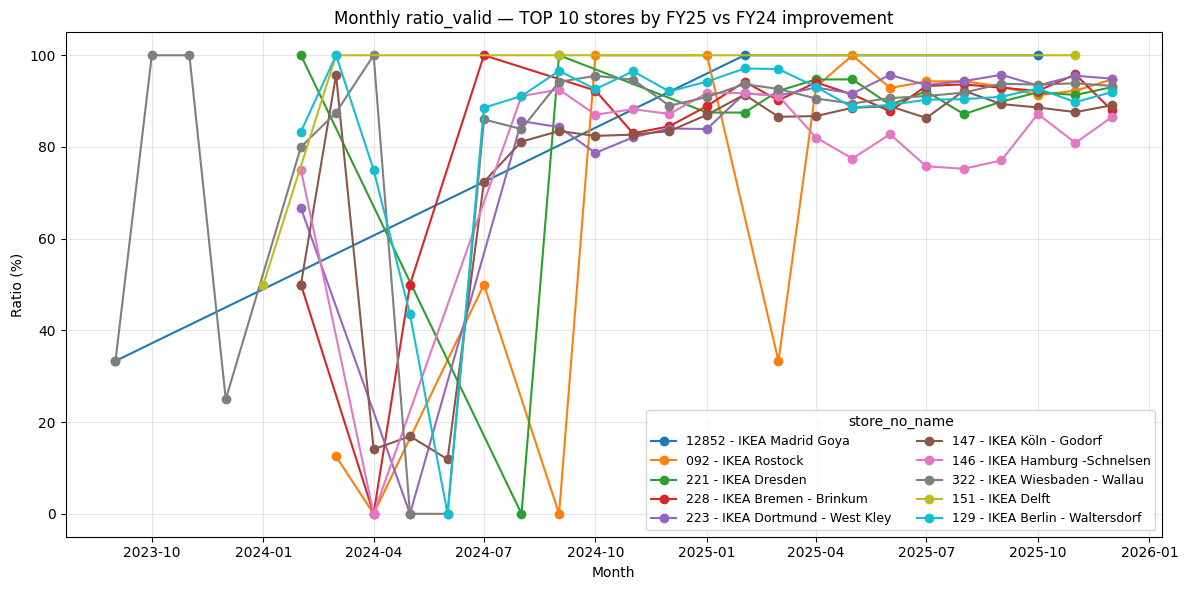

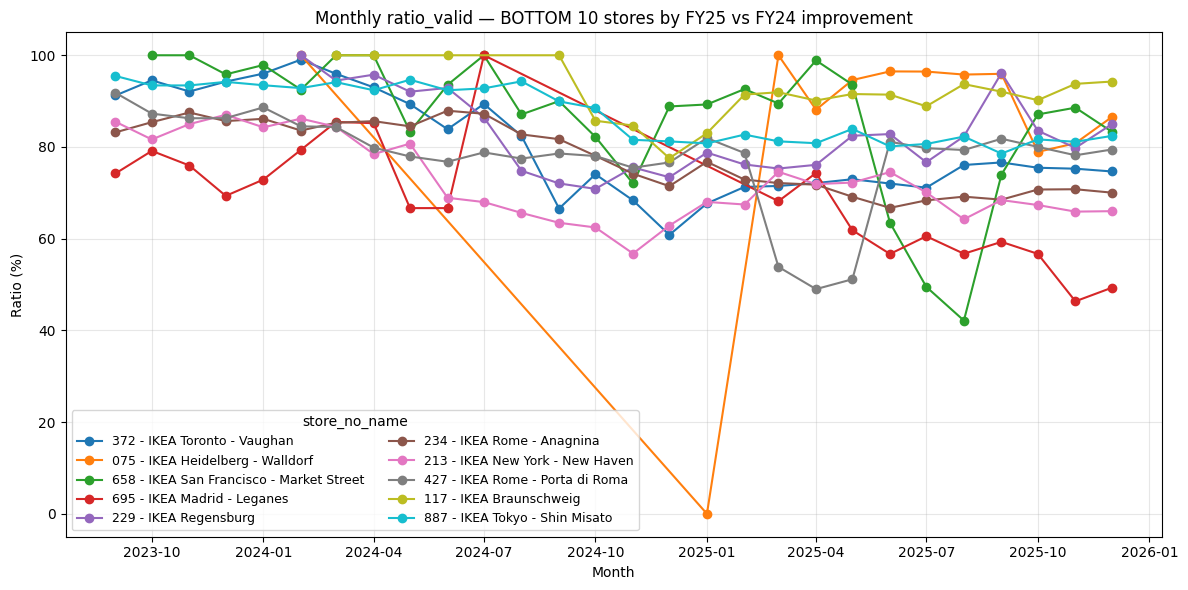

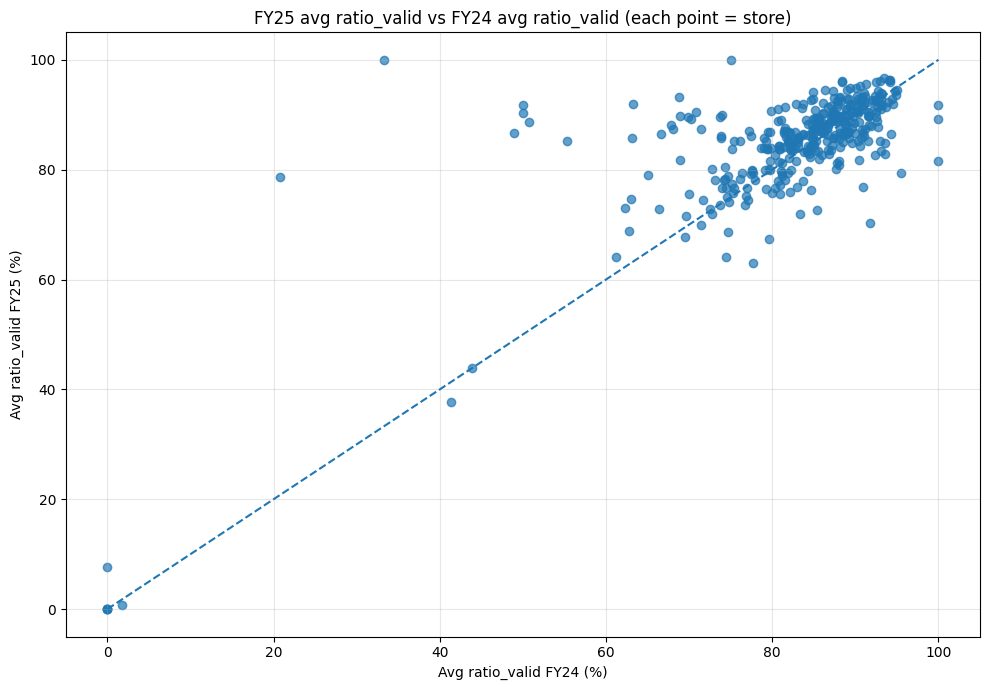

Top 10 improvers:
                       store_no_name  avg_ratio_fy24  avg_ratio_fy25  \
67          12852 - IKEA Madrid Goya       33.333333           100.0   
47                092 - IKEA Rostock       20.833333       78.658903   
129               221 - IKEA Dresden            50.0       91.686297   
136      228 - IKEA Bremen - Brinkum            50.0       90.304129   
131  223 - IKEA Dortmund - West Kley       50.765136       88.678235   
81          147 - IKEA Köln - Godorf       48.875281       86.649649   
80     146 - IKEA Hamburg -Schnelsen       55.365974       85.249012   
189    322 - IKEA Wiesbaden - Wallau       63.249216       92.022783   
84                  151 - IKEA Delft            75.0           100.0   
68   129 - IKEA Berlin - Waltersdorf       68.780755       93.149307   

     improvement_pp  
67        66.666667  
47        57.825569  
129       41.686297  
136       40.304129  
131       37.913099  
81        37.774369  
80        29.883037  
189       28.

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) Prepare month column
# -----------------------------
df = task_location.copy()

s = df["iso_month_no"].astype(str).str.replace("-", "").str.replace("/", "")
df["month"] = pd.to_datetime(s, format="%Y%m", errors="coerce")
mask_nat = df["month"].isna()
df.loc[mask_nat, "month"] = pd.to_datetime(df.loc[mask_nat, "iso_month_no"], errors="coerce")

# -----------------------------
# 1) Aggregate to store-month + ratio
# -----------------------------
store_month = (
    df.groupby(["store_no_name", "month"], as_index=False)
      .agg(total_grid_codes=("total_grid_codes", "sum"),
           total_valid_grid_codes=("total_valid_grid_codes", "sum"))
)
store_month["ratio_valid"] = 100 * store_month["total_valid_grid_codes"] / store_month["total_grid_codes"]

# -----------------------------
# 2) FY24 vs FY25 averages + improvement
# -----------------------------
fy24_start, fy24_end = pd.Timestamp("2023-09-01"), pd.Timestamp("2024-08-31")
fy25_start, fy25_end = pd.Timestamp("2024-09-01"), pd.Timestamp("2025-08-31")

fy24 = store_month[store_month["month"].between(fy24_start, fy24_end)]
fy25 = store_month[store_month["month"].between(fy25_start, fy25_end)]

avg_fy24 = fy24.groupby("store_no_name", as_index=False)["ratio_valid"].mean().rename(columns={"ratio_valid": "avg_ratio_fy24"})
avg_fy25 = fy25.groupby("store_no_name", as_index=False)["ratio_valid"].mean().rename(columns={"ratio_valid": "avg_ratio_fy25"})

improv = avg_fy24.merge(avg_fy25, on="store_no_name", how="inner")
improv["improvement_pp"] = improv["avg_ratio_fy25"] - improv["avg_ratio_fy24"]  # percentage points

# Pick top/bottom 10 by improvement
top10_imp = improv.sort_values("improvement_pp", ascending=False).head(10)["store_no_name"].tolist()
bot10_imp = improv.sort_values("improvement_pp", ascending=True).head(10)["store_no_name"].tolist()

# -----------------------------
# 3) Plot line chart for TOP 10 improvers
# -----------------------------
plt.figure(figsize=(12, 6))
for st in top10_imp:
    tmp = store_month[store_month["store_no_name"] == st].sort_values("month")
    plt.plot(tmp["month"], tmp["ratio_valid"], marker="o", linewidth=1.5, label=f"{st}")
plt.title("Monthly ratio_valid — TOP 10 stores by FY25 vs FY24 improvement")
plt.xlabel("Month")
plt.ylabel("Ratio (%)")
plt.grid(True, alpha=0.3)
plt.legend(title="store_no_name", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Plot line chart for BOTTOM 10 improvers
# -----------------------------
plt.figure(figsize=(12, 6))
for st in bot10_imp:
    tmp = store_month[store_month["store_no_name"] == st].sort_values("month")
    plt.plot(tmp["month"], tmp["ratio_valid"], marker="o", linewidth=1.5, label=f"{st}")
plt.title("Monthly ratio_valid — BOTTOM 10 stores by FY25 vs FY24 improvement")
plt.xlabel("Month")
plt.ylabel("Ratio (%)")
plt.grid(True, alpha=0.3)
plt.legend(title="store_no_name", ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# -----------------------------
# 5) 2D scatter: FY24 avg vs FY25 avg (each point = store)
# -----------------------------
plt.figure(figsize=(10, 7))
plt.scatter(improv["avg_ratio_fy24"], improv["avg_ratio_fy25"], alpha=0.7)

# reference diagonal (no change)
mn = min(improv["avg_ratio_fy24"].min(), improv["avg_ratio_fy25"].min())
mx = max(improv["avg_ratio_fy24"].max(), improv["avg_ratio_fy25"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")  # y=x

plt.title("FY25 avg ratio_valid vs FY24 avg ratio_valid (each point = store)")
plt.xlabel("Avg ratio_valid FY24 (%)")
plt.ylabel("Avg ratio_valid FY25 (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: quick view of extremes
print("Top 10 improvers:")
print(improv.sort_values("improvement_pp", ascending=False).head(10))

print("\nBottom 10 improvers:")
print(improv.sort_values("improvement_pp", ascending=True).head(10))


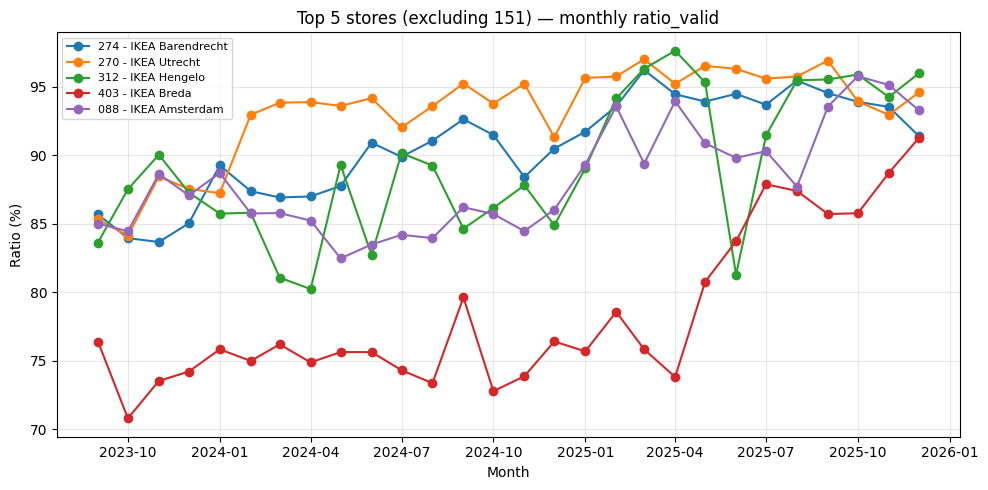

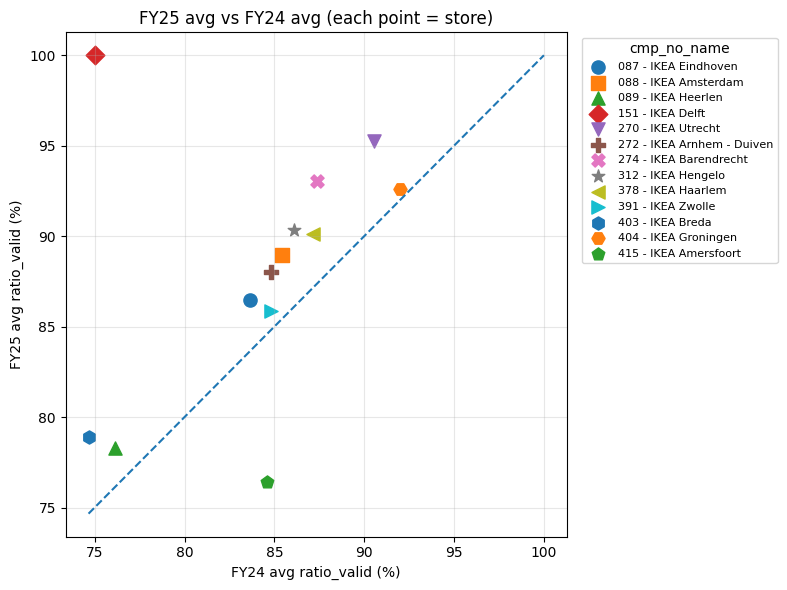

In [112]:
import pandas as pd
import matplotlib.pyplot as plt

stores = ['087','404','151','272','270','274','089','391','403','415','312','088','378']

# filter + month
df = task_location[task_location["store_no"].astype(str).isin(stores)].copy()
df["month"] = pd.to_datetime(df["iso_month_no"].astype(str).str.replace("-","").str.replace("/",""),
                            format="%Y%m", errors="coerce")

# store-month ratio
store_month = df.groupby(["store_no","store_no_name","month"], as_index=False).agg(
    total=("total_grid_codes","sum"),
    valid=("total_valid_grid_codes","sum")
)
store_month["ratio_valid"] = 100 * store_month["valid"] / store_month["total"]

# FY averages
fy24 = store_month[store_month["month"].between("2023-09-01","2024-08-31")]
fy25 = store_month[store_month["month"].between("2024-09-01","2025-08-31")]

avg24 = fy24.groupby(["store_no","store_no_name"], as_index=False)["ratio_valid"].mean().rename(columns={"ratio_valid":"fy24"})
avg25 = fy25.groupby(["store_no","store_no_name"], as_index=False)["ratio_valid"].mean().rename(columns={"ratio_valid":"fy25"})

improv = avg24.merge(avg25, on=["store_no","store_no_name"]).copy()
improv["improvement_pp"] = improv["fy25"] - improv["fy24"]

# TOP 5 (exclude store 151 for the first plot)
top5 = improv[improv["store_no"].astype(str) != "151"].sort_values("improvement_pp", ascending=False).head(5)

# 1) TOP 5 evolution
plt.figure(figsize=(10,5))
for name in top5["store_no_name"]:
    t = store_month[store_month["store_no_name"] == name].sort_values("month")
    plt.plot(t["month"], t["ratio_valid"], marker="o", label=name)

plt.title("Top 5 stores (excluding 151) — monthly ratio_valid")
plt.xlabel("Month"); plt.ylabel("Ratio (%)")
plt.grid(alpha=0.3); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()

# 2) 2D plot with different marker shapes
markers = ['o','s','^','D','v','P','X','*','<','>','h','H','p']

plt.figure(figsize=(8,6))
i = 0
for name in improv["store_no_name"].sort_values():
    r = improv[improv["store_no_name"] == name].iloc[0]
    plt.scatter(r["fy24"], r["fy25"], s=90, marker=markers[i], label=name)
    i += 1

mn = min(improv["fy24"].min(), improv["fy25"].min())
mx = max(improv["fy24"].max(), improv["fy25"].max())
plt.plot([mn, mx], [mn, mx], "--")

plt.title("FY25 avg vs FY24 avg (each point = store)")
plt.xlabel("FY24 avg ratio_valid (%)"); plt.ylabel("FY25 avg ratio_valid (%)")
plt.grid(alpha=0.3)
plt.legend(title="cmp_no_name", bbox_to_anchor=(1.02,1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


### 2.5.3 Consistency slm location

#### check here for 1 month of data in Eindhoven, how many item did change in the same location, the location type and the evolution of those

In [135]:
## check how many article_id/sales_location_id had more than 1 location_type


grouped_check=check_location_id.groupby(['article_id','bu_code','sales_location_id']).agg({
           'location_type' : ['nunique']
        }).reset_index()


grouped_check.columns = grouped_check.columns.map('_'.join)
grouped_check.rename(columns = {
                                'article_id_' : 'article_id',
                                    'bu_code_' : 'bu_code',
                                    'sales_location_id_' : 'sales_location_id',
                      'location_type_nunique' : 'location_type_nunique'
                         }, inplace = True)

In [136]:
grouped_check.loc[grouped_check.location_type_nunique >1]

,article_id,bu_code,sales_location_id,location_type_nunique
220,00307552,087,AA0202,2
221,00307552,087,M18J04,2
222,00307552,087,M18K04,2
233,00311059,087,472700,2
282,00330944,087,172200,2
...,...,...,...,...
16423,90590503,087,LTD001,2
16424,90590503,087,M16E07,2
16439,90591994,087,M18J09,2
16449,90592451,087,LTD001,2


In [137]:
## how many article/location_id changed at least 2 time the location type in this mounth?
display( grouped_check[['article_id', 'sales_location_id']].drop_duplicates().shape[0])

display(grouped_check.loc[grouped_check.location_type_nunique >1].drop_duplicates().shape[0])


display(100*(grouped_check.loc[grouped_check.location_type_nunique >1].drop_duplicates().shape[0] )/
       ( grouped_check[['article_id', 'sales_location_id']].drop_duplicates().shape[0]) )

16583

314

1.8935053970934088

In [138]:
grouped_check.loc[grouped_check.location_type_nunique >1,'check'] = 'yes'
grouped_check.head()

,article_id,bu_code,sales_location_id,location_type_nunique,check
0,00030262,087,M14N22,1,NaN
1,00031841,087,521210,1,NaN
2,00069768,087,132610,1,NaN
3,00069768,087,132710,1,NaN
4,00081534,087,M14I21,1,NaN


In [139]:
merged_orig = pd.merge(
    check_location_id, grouped_check,
    on=['article_id', 'sales_location_id'],
    how='left'
)
merged_orig.head()

,article_id,bu_code_x,sales_location_id,from_date,import_date,location_type,bu_code_y,location_type_nunique,check
0,40590954,087,228800,2025-04-01,2025-03-23,3,087,2,yes
1,00586633,087,228800,2025-04-01,2025-03-23,3,087,1,NaN
2,50586635,087,228800,2025-04-01,2025-03-23,3,087,1,NaN
3,70427315,087,M16F11,2019-05-13,2025-03-23,3,087,1,NaN
4,90427319,087,M16F11,2019-05-13,2025-03-23,3,087,1,NaN


/var/folders/y0/zlfn4n2d0n70dbtgn_63gp0xr3ydtm/T/ipykernel_27372/2745694686.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['import_date'] = pd.to_datetime(df['import_date'])
/var/folders/y0/zlfn4n2d0n70dbtgn_63gp0xr3ydtm/T/ipykernel_27372/2745694686.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['location_type_encoded'] = df['location_type'].astype('category').cat.codes


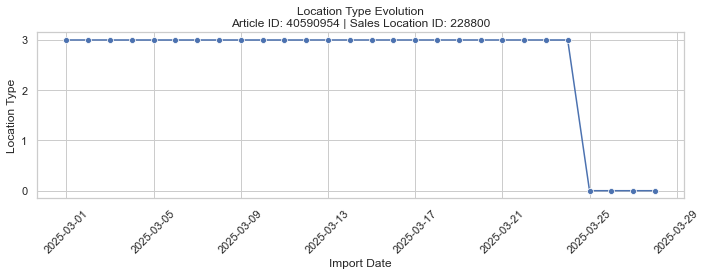

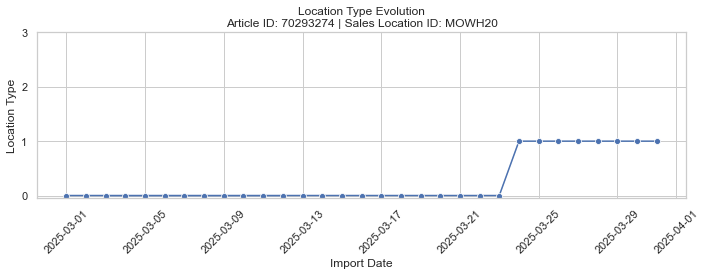

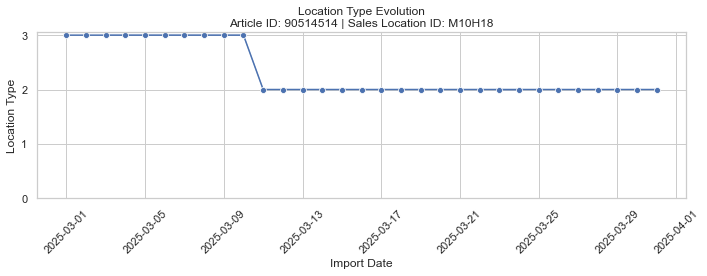

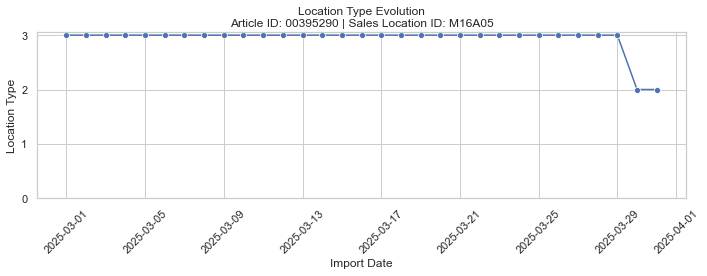

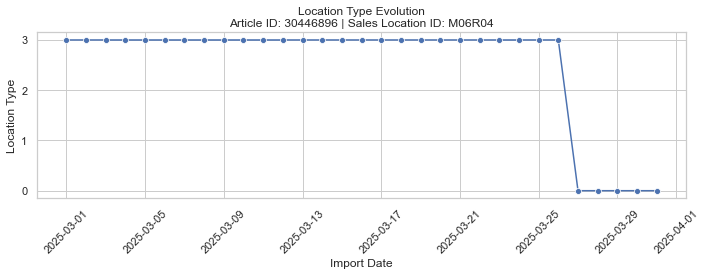

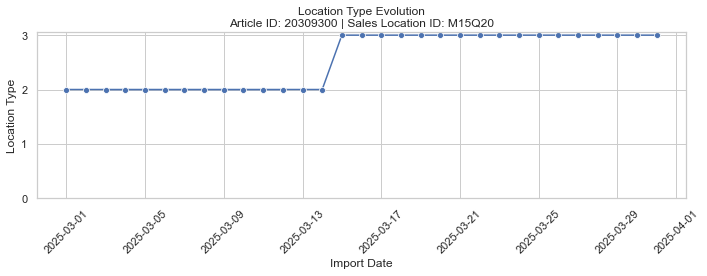

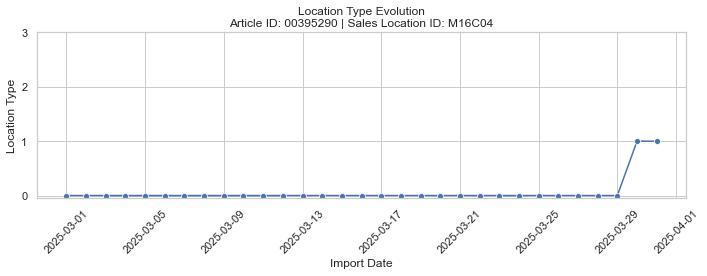

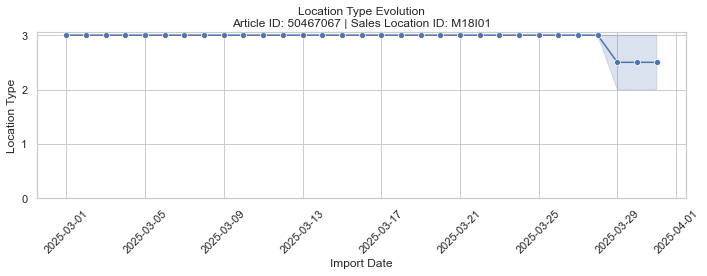

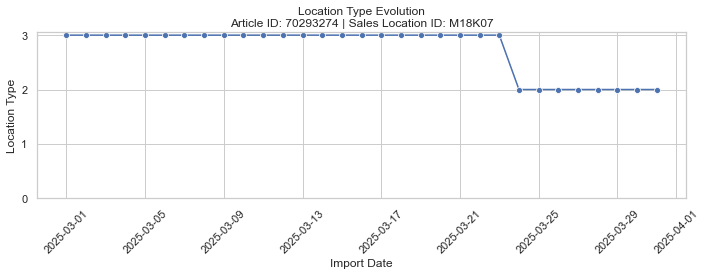

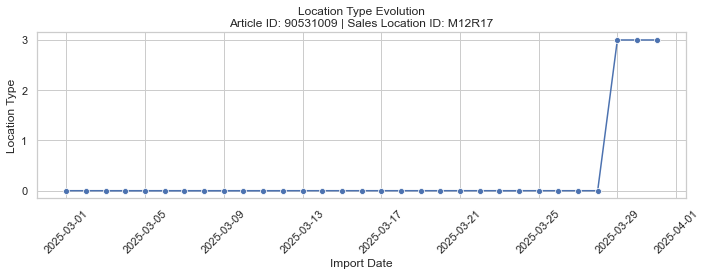

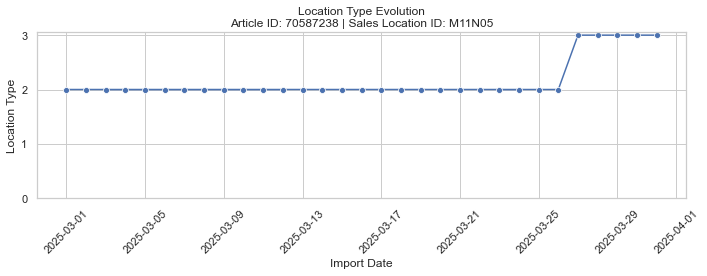

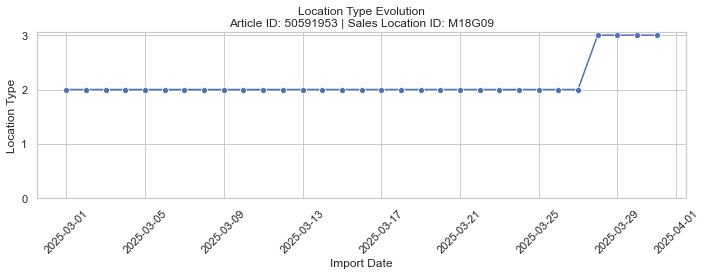

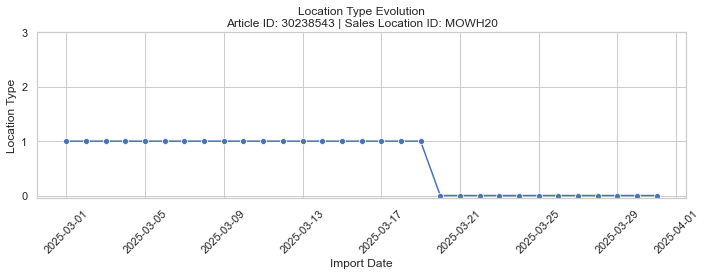

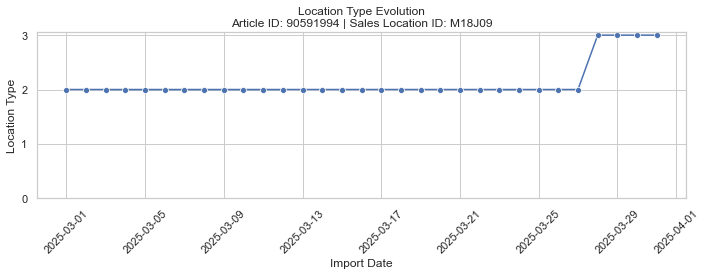

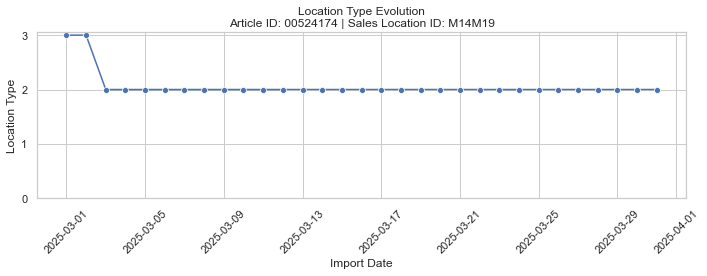

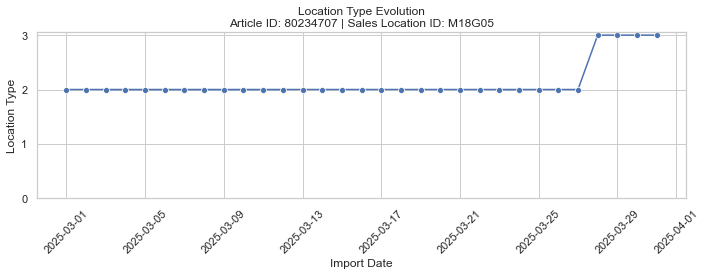

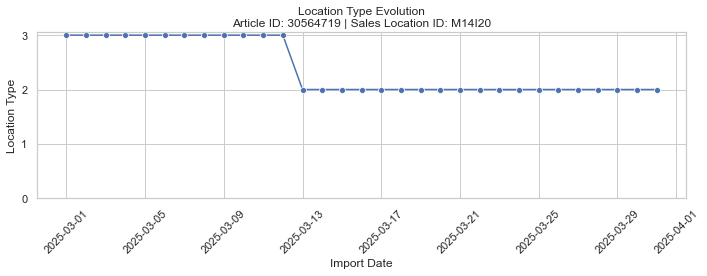

KeyboardInterrupt: 

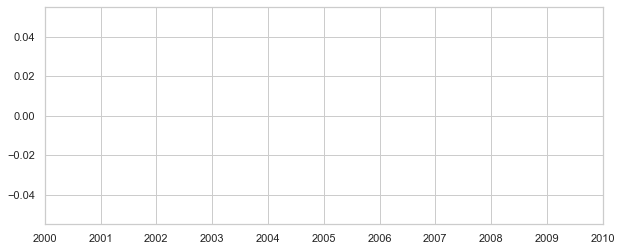

In [44]:
df = merged_orig.loc[merged_orig.check=='yes']
# Ensure 'from_date' is in datetime format
df['import_date'] = pd.to_datetime(df['import_date'])

# Optional: encode 'location_type' if it's categorical (e.g., strings)
df['location_type_encoded'] = df['location_type'].astype('category').cat.codes

# Group by unique combinations
combinations = df[['article_id', 'sales_location_id']].drop_duplicates()

# Plot style
sns.set(style="whitegrid")

# Iterate through each unique (article_id, sales_location_id) pair
for _, row in combinations.iterrows():
    article_id = row['article_id']
    sales_location_id = row['sales_location_id']
    
    subset = df[(df['article_id'] == article_id) & (df['sales_location_id'] == sales_location_id)]
    
    if subset.empty:
        continue

    plt.figure(figsize=(10, 4))
    sns.lineplot(data=subset, x='import_date', y='location_type_encoded', marker='o')
    
    # Optional: map encoded values back to original for y-ticks
    loc_map = dict(enumerate(df['location_type'].astype('category').cat.categories))
    plt.yticks(list(loc_map.keys()), list(loc_map.values()))
    
    plt.title(f'Location Type Evolution\nArticle ID: {article_id} | Sales Location ID: {sales_location_id}')
    plt.xlabel('Import Date')
    plt.ylabel('Location Type')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### 2.5.3.1 Consistency slm location:overall stores

In [140]:
check_uniq_location_type.sort_values(by='perc', ascending=False)

,bu_code,oneloc,gt1loc,perc
152,280,399435,58650,14.683240
213,085,488609,28519,5.836773
328,367,388536,14431,3.714199
203,391,375636,8158,2.171783
16,726,146294,2760,1.886612
...,...,...,...,...
384,716,34390,0,0.000000
320,718,28792,0,0.000000
386,711,326,0,0.000000
385,1008,12700,0,0.000000
